# Machine Learning Assignment

## Question 1: Real-Time Card-Not-Present Fraud Detection for an E-Commerce Payment Gateway

### Objective

The objective of this project is to develop and evaluate a Support Vector Machine (SVM)-based fraud detection system for identifying fraudulent card-not-present transactions in an e-commerce payment gateway. Since fraudulent transactions are significantly rarer than legitimate transactions, the project focuses on handling class imbalance while accurately identifying fraudulent activities.

This notebook follows a complete machine learning workflow including Exploratory Data Analysis (EDA), data preprocessing, feature scaling, Support Vector Machine model development, kernel comparison, stratified cross-validation, hyperparameter tuning, feature selection, and comprehensive model evaluation using metrics appropriate for imbalanced datasets.

### Primary Machine Learning Technique

- Support Vector Machine (SVM)

### Domain

- FinTech
- E-Commerce Payment Fraud Detection


# 1. Dataset in Use

This project uses the **Credit Card Fraud Detection Dataset** available on Kaggle. The dataset contains anonymized transaction features generated using Principal Component Analysis (PCA), along with transaction amount, transaction time, and a binary fraud label indicating whether a transaction is legitimate or fraudulent.

# 2. Environment Setup

In this section, we import all the required Python libraries used throughout this project. These libraries support data manipulation, visualization, preprocessing, model building, hyperparameter tuning, feature selection, evaluation, and cross-validation.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Measure training time
import time

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning utilities
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Support Vector Machine
from sklearn.svm import SVC

# Feature Selection
from sklearn.feature_selection import RFE

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    make_scorer
)

# Set plotting style
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


# 3. Dataset Loading

## 3.1 Dataset Source

This project uses the **Credit Card Fraud Detection** dataset from Kaggle. The dataset contains anonymized credit card transaction records, where the target variable (`Class`) indicates whether a transaction is legitimate (`0`) or fraudulent (`1`).

**Dataset Details**

- **Dataset Name:** Credit Card Fraud Detection
- **Source:** Kaggle
- **URL:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The dataset is widely used as a benchmark for fraud detection research and is recommended in the assignment for building a Support Vector Machine (SVM)-based fraud detection system.

## 3.2 Upload Dataset

The dataset is uploaded into the Google Colab environment using Colab's file upload utility. Once uploaded, it becomes temporarily available within the current notebook session.

## 3.3 Load Dataset

After uploading the dataset, it is loaded into a Pandas DataFrame. Pandas provides efficient tools for reading, storing, and analyzing tabular datasets.

In [2]:
# ==========================================
# Load Dataset
# ==========================================

import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3.4 Initial Dataset Inspection

Before beginning the analysis, it is important to verify that the dataset has been loaded correctly. The following commands display the first few rows of the dataset, its dimensions, column names, and data types.

In [5]:
# ==========================================
# Inspect Dataset
# ==========================================

print("=" * 60)
print("First Five Rows")
print("=" * 60)

display(df.head())

print("\n")

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)

print(df.columns.tolist())

First Five Rows


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0




Dataset Shape
(284807, 31)


Column Names
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 3.5 Dataset Information

Before performing Exploratory Data Analysis (EDA), it is important to inspect the overall structure of the dataset. This includes examining the number of entries, data types of each feature, non-null value counts, and memory usage. Understanding this information helps identify potential data quality issues, such as missing values or incorrect data types, that may require preprocessing before model development.

In [6]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## **3.6 Summary**

The Credit Card Fraud Detection dataset was successfully uploaded and loaded into the Google Colab environment using the Pandas library. Initial inspection confirmed that the dataset contains **284,807 transaction records** and **31 columns**, consisting of **30 input features** (`Time`, `V1`–`V28`, and `Amount`) and one target variable (`Class`) representing whether a transaction is legitimate (`0`) or fraudulent (`1`).

The dataset information revealed that all **284,807 entries are complete**, with no missing values in any feature. The predictor variables are numerical (`float64`), while the target variable is stored as an integer (`int64`), making the dataset well-suited for Support Vector Machine (SVM) classification after appropriate preprocessing.

Overall, the dataset has been successfully loaded, verified, and inspected. Since no immediate data quality issues were identified during this initial inspection, we can confidently proceed to Exploratory Data Analysis (EDA) to better understand the dataset characteristics and class distribution.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, quality, and characteristics of the dataset before model development. In this section, the dataset is examined for missing values, duplicate records, statistical properties, class imbalance, feature distributions, and relationships between variables. These analyses provide valuable insights that guide preprocessing and help assess the suitability of Support Vector Machines (SVM) for fraud detection.

## 4.1 Dataset Overview

The first step of Exploratory Data Analysis is to obtain a general overview of the dataset. This includes examining descriptive statistics for each numerical feature to understand their distribution, central tendency, and variability. These statistics provide an initial understanding of the data before more detailed analyses are performed.

In [7]:
# ======================================================
# Dataset Statistical Overview
# ======================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### **Interpretation**

The statistical summary provides an initial understanding of the numerical features in the dataset. Since the majority of the predictor variables (`V1`–`V28`) were generated using Principal Component Analysis (PCA), their mean values are close to zero, which is consistent with PCA-transformed data.

The `Amount` feature exhibits a wide range of transaction values, varying from **0** to approximately **25,691**, while the mean transaction amount (**88.35**) is substantially higher than the median (**22.00**). This indicates that the distribution of transaction amounts is positively skewed, with a small number of high-value transactions.

The target variable (`Class`) is binary, containing only the values **0** (legitimate transaction) and **1** (fraudulent transaction). The descriptive statistics also suggest that fraudulent transactions represent only a very small proportion of the dataset, indicating a highly imbalanced classification problem. This class imbalance will be examined in greater detail later in the EDA.

## 4.2 Missing Value Analysis

Missing values can reduce the quality of a machine learning model and may require additional preprocessing before training. Therefore, the dataset is examined to determine whether any features contain missing observations. Identifying missing values at an early stage helps ensure that appropriate preprocessing steps can be applied if necessary.

In [8]:
# ======================================================
# Missing Value Analysis
# ======================================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


### **Interpretation**

The missing value analysis shows that all features contain **zero missing values**, indicating that the dataset is complete. Since no missing observations are present, no imputation or missing value handling techniques are required during the preprocessing stage.

This is beneficial for model development because the dataset can be used directly for training after the required preprocessing steps, such as feature scaling.

## 4.3 Duplicate Value Analysis

Duplicate records can affect machine learning model performance by introducing redundant information and potentially biasing the learning process. Therefore, the dataset is examined to determine whether duplicate transactions are present and whether duplicate removal is required before model training.

In [9]:
# ======================================================
# Duplicate Value Analysis
# ======================================================

duplicate_count = df.duplicated().sum()

duplicate_summary = pd.DataFrame({
    "Total Duplicate Records": [duplicate_count],
    "Duplicate Percentage (%)": [(duplicate_count / len(df)) * 100]
})

duplicate_summary

,Total Duplicate Records,Duplicate Percentage (%)
0,1081,0.379555


### **Interpretation**

The duplicate value analysis identified **1,081 duplicate records**, representing approximately **0.38%** of the dataset. Although the proportion of duplicate transactions is relatively small, duplicate records can introduce redundancy and potentially bias the learning process by overrepresenting certain observations.

At this stage, the duplicates are only identified and documented as part of the exploratory analysis. A decision regarding whether these duplicate records should be removed will be made during the data preprocessing stage after considering their potential impact on model performance.

## 4.4 Class Distribution Analysis

In fraud detection problems, fraudulent transactions typically represent only a small fraction of all transactions. Such datasets are known as **imbalanced datasets**, where one class contains significantly fewer observations than the other.

Analyzing the class distribution helps quantify the severity of this imbalance and provides important insights into the challenges that the machine learning model may encounter during training and evaluation.

In [10]:
# ======================================================
# Class Distribution
# ======================================================

class_counts = df["Class"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Transaction Class": ["Legitimate (0)", "Fraudulent (1)"],
    "Number of Transactions": class_counts.values,
    "Percentage (%)": ((class_counts / len(df)) * 100).round(4)
})

# Remove the index name for a cleaner display
class_distribution.index.name = None

display(class_distribution)

,Transaction Class,Number of Transactions,Percentage (%)
0,Legitimate (0),284315,99.8273
1,Fraudulent (1),492,0.1727


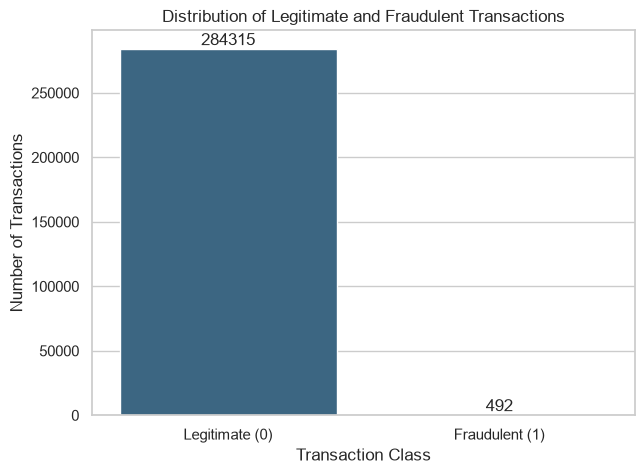

In [11]:
# ======================================================
# Class Distribution Bar Plot
# ======================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="Class",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

ax.set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

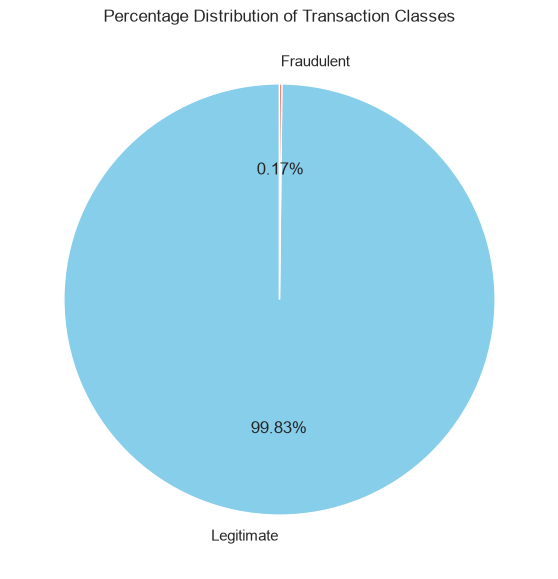

In [12]:
# ======================================================
# Class Distribution Pie Chart
# ======================================================

plt.figure(figsize=(7,7))

plt.pie(
    class_counts,
    labels=["Legitimate", "Fraudulent"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["skyblue", "tomato"]
)

plt.title("Percentage Distribution of Transaction Classes")

plt.show()

### **Interpretation**

The class distribution analysis confirms that the dataset is **highly imbalanced**. Out of **284,807 transactions**, **284,315 (99.83%)** are legitimate, while only **492 (0.17%)** are fraudulent.

Such a severe imbalance presents a significant challenge for machine learning models because they may become biased toward predicting the majority class. As a result, evaluation metrics such as **precision**, **recall**, **F1-score**, and **Precision-Recall AUC** are more appropriate than overall accuracy for assessing fraud detection performance.

This observation also justifies the later use of **Stratified Cross-Validation**, which preserves the fraud-to-legitimate ratio across all validation folds.

## 4.5 Feature Distribution Analysis

Understanding the distribution of important features provides insight into the characteristics of the dataset before comparing fraudulent and legitimate transactions. In this section, selected features are visualized to examine their distribution, identify skewness, and observe the presence of potential outliers. These observations help provide context for the fraud detection problem.

### 4.5.1 Distribution of Transaction Amount

The `Amount` feature represents the monetary value of each transaction. Examining its distribution helps determine whether transaction amounts are evenly distributed or concentrated within a particular range. It also helps identify the presence of unusually large transactions that may influence model training.

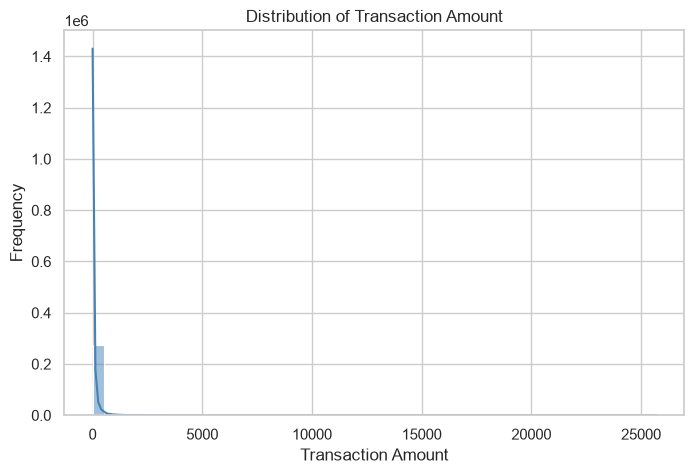

In [13]:
# ======================================================
# Distribution of Transaction Amount
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

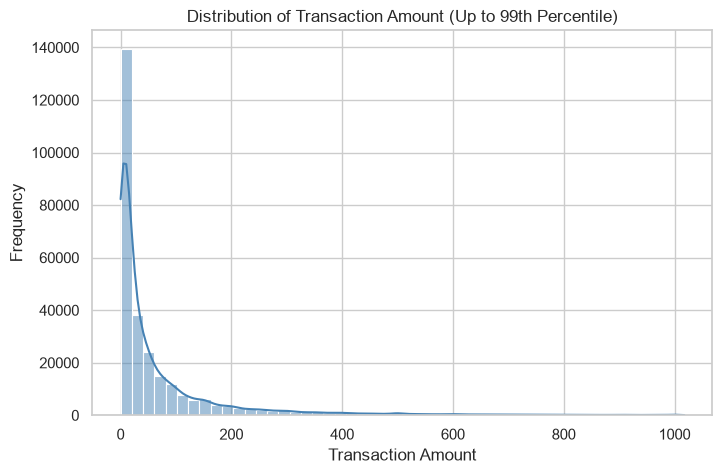

In [14]:
# ======================================================
# Distribution of Transaction Amount
# ======================================================

plt.figure(figsize=(8,5))

amount_limit = df["Amount"].quantile(0.99)

sns.histplot(
    df[df["Amount"] <= amount_limit]["Amount"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Transaction Amount (Up to 99th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

### 4.5.2 Distribution of Transaction Time

The `Time` feature represents the elapsed time between each transaction and the first transaction recorded in the dataset. Examining its distribution provides an overview of how transactions are distributed throughout the observation period.

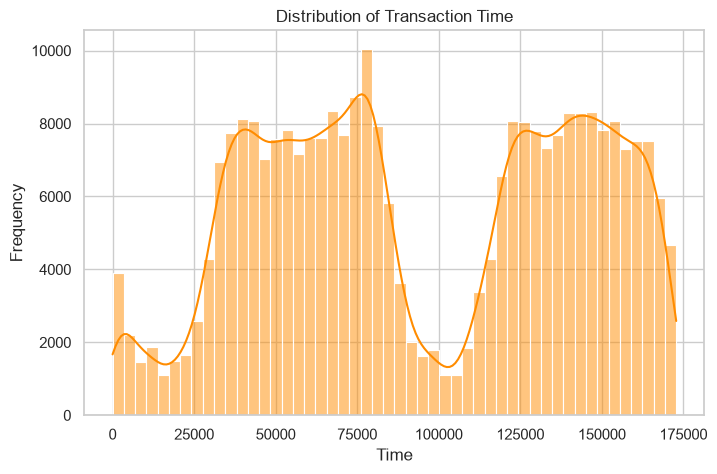

In [15]:
# ======================================================
# Distribution of Transaction Time
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["Time"],
    bins=50,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

### **Interpretation**

The feature distributions indicate that transaction amounts are highly concentrated at lower values, with a relatively small number of high-value transactions. This results in a positively skewed distribution and suggests the presence of outliers in the `Amount` feature.

The distribution of the `Time` feature reflects how transactions are spread throughout the data collection period. Unlike the `Amount` feature, the `Time` variable does not represent a financial quantity but rather the chronological order of transactions.

These observations provide useful context for understanding the dataset before examining how fraudulent and legitimate transactions differ across selected features.

## 4.6 Fraud vs. Legitimate Transaction Comparison

To examine the separability between legitimate and fraudulent transactions, selected features are compared across both classes. Boxplots are used because they effectively summarize the distribution of each feature by displaying the median, spread, and potential outliers. Observing differences between the two classes provides an initial indication of whether the selected features may help distinguish fraudulent transactions from legitimate ones.

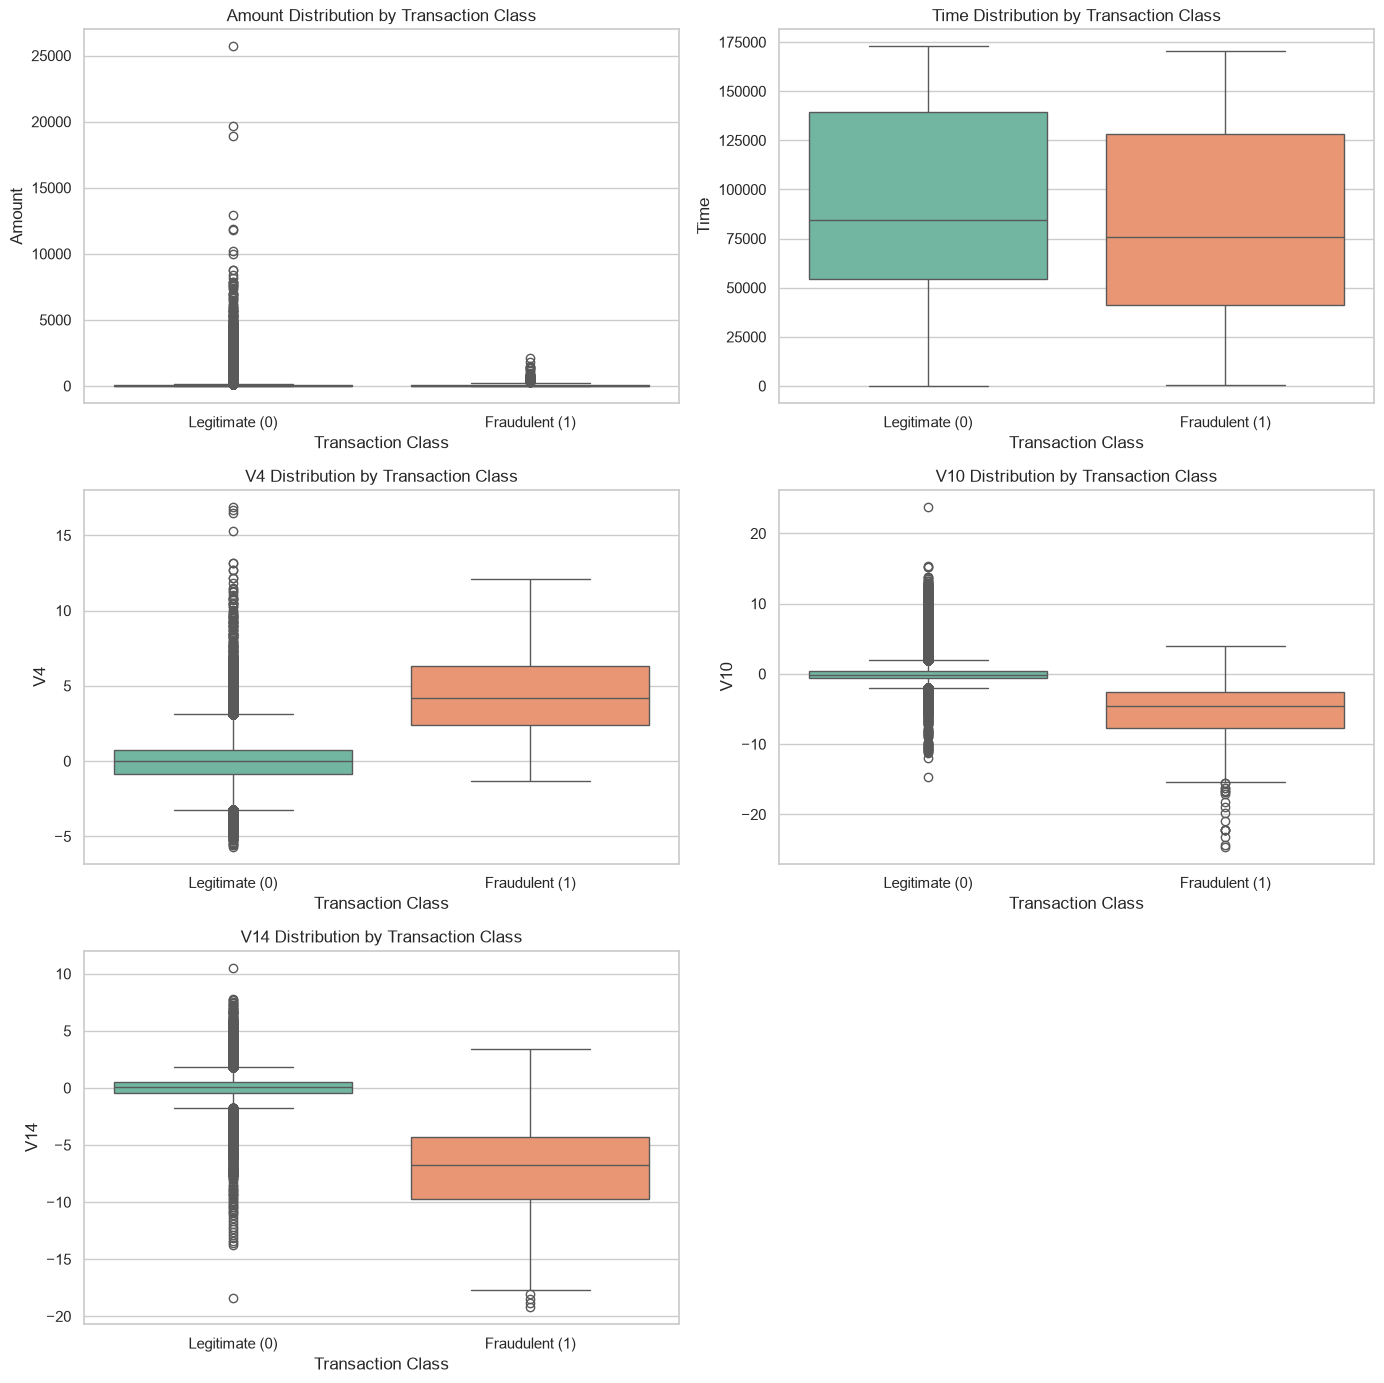

In [16]:
# ======================================================
# Fraud vs Legitimate Transaction Comparison
# ======================================================

selected_features = ["Amount", "Time", "V4", "V10", "V14"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

axes = axes.flatten()

for i, feature in enumerate(selected_features):

    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"{feature} Distribution by Transaction Class")
    axes[i].set_xlabel("Transaction Class")
    axes[i].set_ylabel(feature)

    axes[i].set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### **Interpretation**

The comparison of feature distributions reveals varying levels of separability between legitimate and fraudulent transactions. The original features, **Amount** and **Time**, exhibit substantial overlap between the two classes, indicating that they are not individually sufficient for distinguishing fraudulent transactions.

In contrast, the PCA-transformed features **V4**, **V10**, and **V14** display noticeably different distributions for legitimate and fraudulent transactions. These differences suggest that the transformed features capture underlying patterns associated with fraudulent behaviour and may provide useful discriminatory information for classification.

Although no single feature perfectly separates the two classes, the combined information from multiple features is likely to improve classification performance. This supports the use of a multivariate machine learning algorithm such as the Support Vector Machine (SVM), which can learn decision boundaries using all available features simultaneously.

## 4.7 Correlation Analysis

A correlation matrix is used to examine the linear relationships between numerical features in the dataset. Correlation coefficients range from **-1** to **1**, where values close to **1** indicate a strong positive relationship, values close to **-1** indicate a strong negative relationship, and values close to **0** indicate little or no linear relationship.

Although many features in this dataset have been transformed using Principal Component Analysis (PCA), the correlation matrix still provides a useful high-level overview of the relationships among the numerical variables.

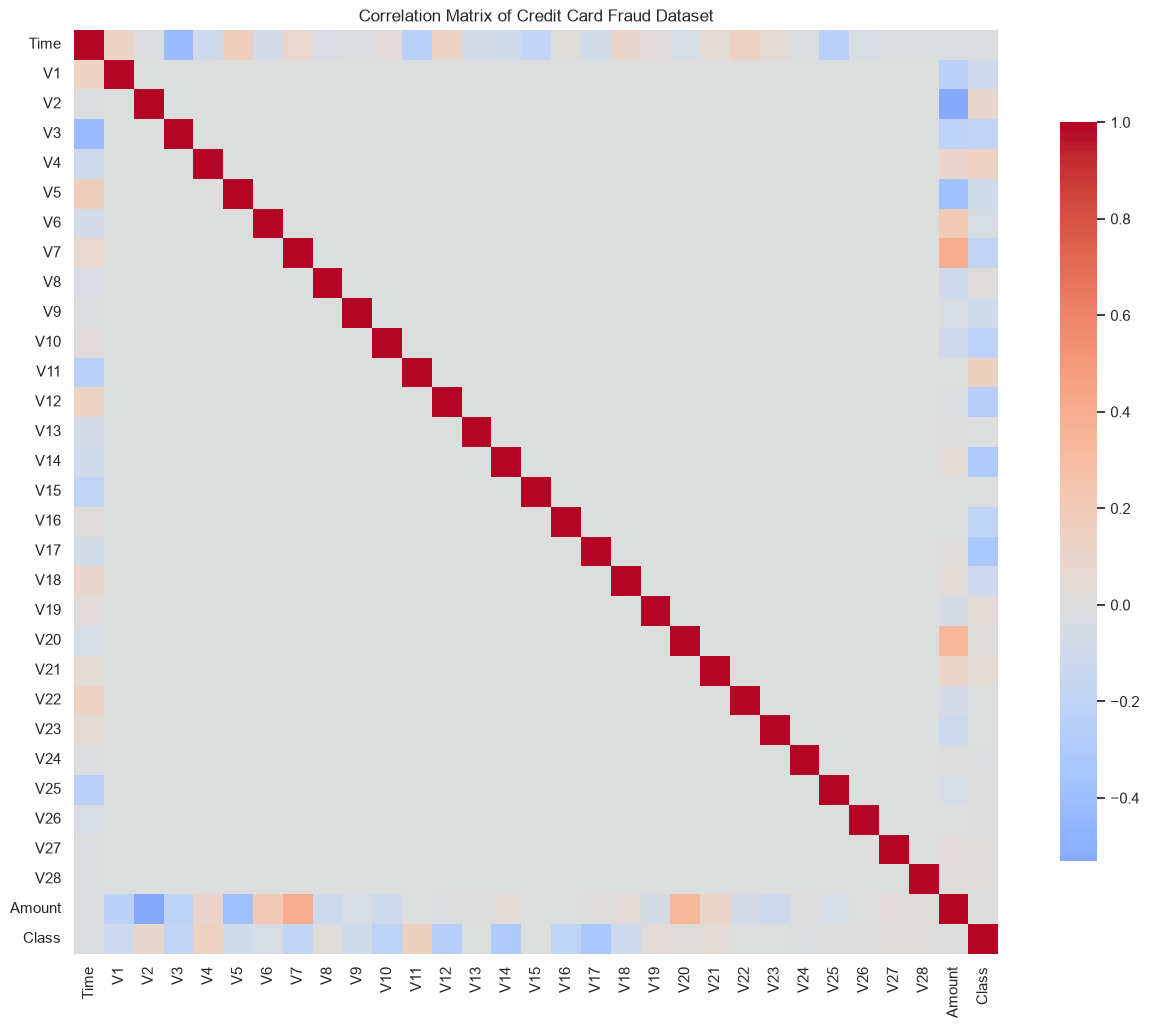

In [17]:
# ======================================================
# Correlation Heatmap
# ======================================================

plt.figure(figsize=(16, 12))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Credit Card Fraud Dataset")
plt.savefig("corr_image")
plt.show()

### **Interpretation**

The correlation heatmap shows that the majority of feature pairs exhibit weak linear correlations, as indicated by the predominance of neutral colours across the matrix. Only a small number of feature pairs display moderate positive or negative correlations.

This pattern is expected because most predictor variables (`V1`–`V28`) were generated using Principal Component Analysis (PCA), which produces transformed features with reduced redundancy and limited linear dependence.

Although a few PCA features exhibit noticeable correlations with the target variable (`Class`), correlation alone should not be interpreted as feature importance. The Support Vector Machine (SVM) will utilize the combined information from all input features to learn decision boundaries for fraud detection.

### **4.8 EDA Summary**

The exploratory analysis provided a comprehensive understanding of the Credit Card Fraud Detection dataset. Initial inspection confirmed that the dataset is complete, with no missing values, although a small number of duplicate records were identified for consideration during preprocessing.

The analysis revealed that the dataset is **highly imbalanced**, with legitimate transactions accounting for approximately **99.83%** of all observations and fraudulent transactions representing only **0.17%**. This severe imbalance highlights the importance of using appropriate evaluation metrics and stratified validation techniques during model development.

Feature distribution analysis showed that transaction amounts are strongly right-skewed, while the transaction time is distributed throughout the observation period. Comparing legitimate and fraudulent transactions demonstrated that the original features (`Amount` and `Time`) exhibit considerable overlap, whereas several PCA-transformed features (`V4`, `V10`, and `V14`) display noticeable differences between the two classes.

Finally, the correlation analysis indicated that most feature pairs have weak linear relationships, which is consistent with the PCA transformation applied to the original variables. Overall, the EDA provided valuable insights into the dataset characteristics and established a solid foundation for the subsequent preprocessing and Support Vector Machine (SVM) model development.

# 5. Data Preprocessing

Data preprocessing prepares the dataset for machine learning by improving data quality and ensuring that the input features are in an appropriate format for model training. In this section, duplicate records are handled, the dataset is divided into input features and the target variable, the data is split into training and testing sets, and feature scaling is applied. These preprocessing steps are particularly important for Support Vector Machines (SVMs), which are sensitive to the scale of the input features.

## 5.1 Duplicate Removal

During Exploratory Data Analysis (EDA), a small number of duplicate records were identified. Duplicate observations may overrepresent certain transactions and potentially bias the learning process. Therefore, duplicate records are removed before model development while preserving all unique transactions.

In [18]:
# ======================================================
# Remove Duplicate Records
# ======================================================

print("=" * 60)
print("Dataset Shape Before Removing Duplicates")
print("=" * 60)

print(df.shape)

# Remove duplicates
df = df.drop_duplicates()

print("\n")

print("=" * 60)
print("Dataset Shape After Removing Duplicates")
print("=" * 60)

print(df.shape)

print("\n")

print("=" * 60)
print("Duplicates Remaining")
print("=" * 60)

print(df.duplicated().sum())

Dataset Shape Before Removing Duplicates
(284807, 31)


Dataset Shape After Removing Duplicates
(283726, 31)


Duplicates Remaining
0


### **Interpretation**

A total of **1,081 duplicate records** were removed from the dataset, reducing the number of transactions from **284,807** to **283,726**. After duplicate removal, no duplicate observations remain in the dataset.

Removing duplicate records helps reduce redundancy and prevents certain transactions from being overrepresented during model training. The cleaned dataset will be used for all subsequent preprocessing and machine learning tasks.

## 5.2 Feature and Target Separation

Machine learning models require the dataset to be divided into **input features** and the **target variable**. The input features contain the information used for prediction, while the target variable represents the outcome that the model is trained to predict.

For this dataset, all columns except `Class` are used as input features, whereas the `Class` column serves as the target variable.

In [19]:
# ======================================================
# Feature and Target Separation
# ======================================================

# Input Features
X = df.drop("Class", axis=1)

# Target Variable
y = df["Class"]

print("=" * 60)
print("Feature Matrix Shape")
print("=" * 60)
print(X.shape)

print("\n")

print("=" * 60)
print("Target Vector Shape")
print("=" * 60)
print(y.shape)

Feature Matrix Shape
(283726, 30)


Target Vector Shape
(283726,)


### **Interpretation**

The dataset has been successfully separated into the input feature matrix (`X`) and the target variable (`y`). The feature matrix contains **30 predictor variables**, while the target vector contains the binary class labels indicating whether each transaction is legitimate or fraudulent.

This separation prepares the dataset for the subsequent train-test split and machine learning model development.

## 5.3 Train-Test Split

To evaluate the machine learning model fairly, the dataset is divided into separate training and testing sets. The training set is used to learn the model parameters, while the testing set is reserved for evaluating model performance on previously unseen data.

Since the dataset is highly imbalanced, **stratified sampling** is used during the train-test split to preserve the proportion of legitimate and fraudulent transactions in both subsets.

In [20]:
# ======================================================
# Train-Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Training Feature Shape")
print("=" * 60)
print(X_train.shape)

print("\n")

print("=" * 60)
print("Testing Feature Shape")
print("=" * 60)
print(X_test.shape)

print("\n")

print("=" * 60)
print("Training Target Shape")
print("=" * 60)
print(y_train.shape)

print("\n")

print("=" * 60)
print("Testing Target Shape")
print("=" * 60)
print(y_test.shape)

Training Feature Shape
(226980, 30)


Testing Feature Shape
(56746, 30)


Training Target Shape
(226980,)


Testing Target Shape
(56746,)


### 5.3.1 Verification of Stratified Sampling

To confirm that stratified sampling was applied correctly, the class distribution of the original dataset, training set, and testing set is compared. Similar percentages across all three datasets indicate that the original class imbalance has been successfully preserved.

In [21]:
# ======================================================
# Verify Stratified Train-Test Split
# ======================================================

comparison = pd.DataFrame({
    "Original Dataset (%)": (y.value_counts(normalize=True) * 100).round(4),
    "Training Set (%)": (y_train.value_counts(normalize=True) * 100).round(4),
    "Testing Set (%)": (y_test.value_counts(normalize=True) * 100).round(4)
})

comparison.index = ["Legitimate (0)", "Fraudulent (1)"]

display(comparison)

,Original Dataset (%),Training Set (%),Testing Set (%)
Legitimate (0),99.8333,99.8335,99.8326
Fraudulent (1),0.1667,0.1665,0.1674


### **Interpretation**

The comparison confirms that stratified sampling successfully preserved the original class distribution in both the training and testing datasets. The percentage of legitimate and fraudulent transactions remains nearly identical across all subsets.

Maintaining the original class distribution is particularly important for highly imbalanced datasets because it ensures that both training and evaluation are performed on representative samples of the data.

## 5.4 Feature Scaling

Feature scaling is an essential preprocessing step for Support Vector Machines (SVMs). Since SVMs calculate distances between data points when constructing decision boundaries, features with larger numerical ranges can disproportionately influence the model.

To prevent this issue, the features are standardized using **StandardScaler**, which transforms each feature to have a mean of approximately **0** and a standard deviation of approximately **1**. The scaler is fitted only on the training data to prevent information from the testing data leaking into the training process.

In [22]:
# ======================================================
# Feature Scaling
# ======================================================

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("Training Data Shape After Scaling")
print("=" * 60)
print(X_train_scaled.shape)

print("\n")

print("=" * 60)
print("Testing Data Shape After Scaling")
print("=" * 60)
print(X_test_scaled.shape)

Training Data Shape After Scaling
(226980, 30)


Testing Data Shape After Scaling
(56746, 30)


### 5.4.1 Verification of Feature Scaling

To verify that feature scaling has been applied correctly, the mean and standard deviation of the scaled training features are examined. After standardization, the feature means should be approximately **0**, and the standard deviations should be approximately **1**.

In [24]:
# ======================================================
# Verify Feature Scaling
# ======================================================

scaled_summary = pd.DataFrame({
    "Mean": X_train_scaled.mean(axis=0),
    "Standard Deviation": X_train_scaled.std(axis=0)
})

scaled_summary.head()

,Mean,Standard Deviation
0,-1.522636e-16,1.0
1,6.699099e-18,1.0
2,-1.202081e-17,1.0
3,8.514742e-18,1.0
4,-2.654596e-17,1.0


### **5.5 Summary**

The dataset was successfully prepared for machine learning through a series of preprocessing steps. Duplicate records identified during the exploratory analysis were removed, resulting in a cleaned dataset containing **283,726 unique transactions**. The dataset was then separated into the input feature matrix (`X`) and the target variable (`y`).

To enable reliable model evaluation, the cleaned dataset was divided into training and testing subsets using an **80:20 stratified split**, ensuring that the original class imbalance was preserved in both datasets. Finally, feature scaling was performed using **StandardScaler**, with the scaler fitted only on the training data to prevent data leakage. The scaled datasets are now ready for Support Vector Machine (SVM) model development and evaluation.

# 6. Baseline Support Vector Machine (Linear Kernel)

Support Vector Machines (SVMs) are supervised machine learning algorithms that classify data by identifying an optimal decision boundary between classes. In this section, a **linear kernel** is used to build a baseline SVM classifier. This baseline provides a reference for evaluating whether more complex non-linear kernels improve fraud detection performance in later sections.

## 6.1 Model Training

The baseline model is trained using a **linear kernel** without hyperparameter tuning. The objective of this model is to establish an initial performance benchmark before experimenting with more complex kernel functions and optimized model configurations.

In [107]:
# ======================================================
# Setting up Baseline Linear SVM
# ======================================================


import time
from sklearn.svm import SVC




# Create the baseline SVM model
svm_linear = SVC(
    kernel="linear",
    random_state=42
)

print("Baseline Linear SVM Setup Done")


Baseline Linear SVM Setup Done


In [108]:
# ======================================================
# Train Baseline Linear SVM
# ======================================================


print("=" * 60)
print("Training Linear SVM...")
print("=" * 60)

start_time = time.time()


svm_linear.fit(X_train_scaled, y_train)

end_time = time.time()


linear_training_time = end_time - start_time

print("\n")

print("=" * 60)
print("Baseline Linear SVM Training Completed Successfully")
print("=" * 60)

print(f"Training Time: {end_time - start_time:.2f} seconds")

Training Linear SVM...


Baseline Linear SVM Training Completed Successfully
Training Time: 3257.23 seconds


## 6.2 Model Prediction

After training the baseline Linear SVM, the model is used to predict the class labels for the unseen testing dataset. These predictions will be used to evaluate the classifier using the performance metrics specified in the assignment.

In [109]:
# ======================================================
# Generate Predictions
# ======================================================

# Predict class labels on the testing data
y_pred_linear = svm_linear.predict(X_test_scaled)

print("=" * 60)
print("Predictions Generated Successfully")
print("=" * 60)

print(f"Number of Predictions: {len(y_pred_linear)}")

Predictions Generated Successfully
Number of Predictions: 56746


## 6.3 Model Evaluation

The baseline Linear SVM is evaluated using multiple performance metrics. Since credit card fraud detection is a highly imbalanced classification problem, relying solely on accuracy can be misleading. Therefore, additional metrics including **Precision**, **Recall**, **F1-score**, **Precision-Recall AUC**, **Confusion Matrix**, and the **Classification Report** are used to provide a comprehensive assessment of model performance.

In [110]:
# ======================================================
# Baseline Linear SVM Evaluation
# ======================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report
)

# Basic Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_linear)
precision = precision_score(y_test, y_pred_linear)
recall = recall_score(y_test, y_pred_linear)
f1 = f1_score(y_test, y_pred_linear)

# Precision-Recall AUC
pr_auc = average_precision_score(y_test, y_pred_linear)

print("=" * 60)
print("Baseline Linear SVM Performance")
print("=" * 60)

print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision             : {precision:.4f}")
print(f"Recall                : {recall:.4f}")
print(f"F1-score              : {f1:.4f}")
print(f"Precision-Recall AUC  : {pr_auc:.4f}")

print("\n")

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_linear))

Baseline Linear SVM Performance
Accuracy              : 0.9994
Precision             : 0.8659
Recall                : 0.7474
F1-score              : 0.8023
Precision-Recall AUC  : 0.6475


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.75      0.80        95

    accuracy                           1.00     56746
   macro avg       0.93      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746



### **Interpretation**

The baseline Linear Support Vector Machine achieved an overall **accuracy of 99.94%** on the testing dataset. While this value appears exceptionally high, accuracy alone is not sufficient for evaluating performance on this highly imbalanced fraud detection problem.

The model achieved a **precision of 86.59%**, indicating that most transactions predicted as fraudulent were indeed fraud cases. The **recall of 74.74%** shows that the model successfully detected approximately three-quarters of all fraudulent transactions, although some fraud cases remained undetected. The resulting **F1-score of 80.23%** reflects a good balance between precision and recall.

The **Precision-Recall AUC of 0.6475** provides a more informative evaluation for this imbalanced dataset and serves as a baseline for comparison with more advanced SVM kernels and tuned models. Overall, the baseline Linear SVM demonstrates strong performance while leaving room for improvement through kernel selection, hyperparameter tuning, and feature selection.

### 6.3.1 Confusion Matrix

A confusion matrix provides a detailed breakdown of the model's predictions by comparing the predicted class labels with the actual class labels. Unlike overall accuracy, the confusion matrix identifies the numbers of **True Positives (TP)**, **True Negatives (TN)**, **False Positives (FP)**, and **False Negatives (FN)**, making it particularly valuable for evaluating fraud detection systems.

<Figure size 600x600 with 0 Axes>

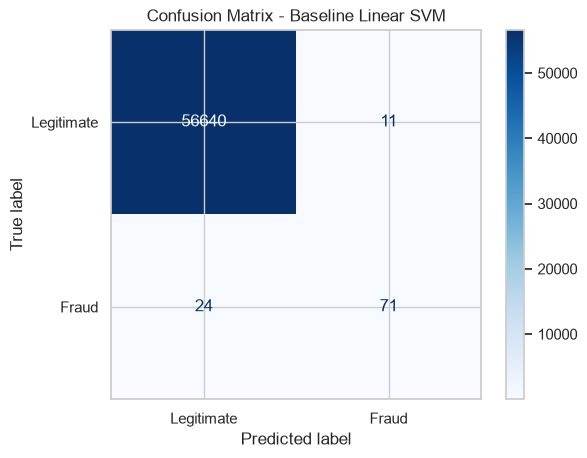

Confusion Matrix
[[56640    11]
 [   24    71]]


In [111]:
# ======================================================
# Confusion Matrix
# ======================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_linear)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Baseline Linear SVM")

plt.show()

print("=" * 60)
print("Confusion Matrix")
print("=" * 60)
print(cm)

### **Interpretation**

The confusion matrix provides a detailed breakdown of the baseline Linear SVM's predictions. Out of **56,651 legitimate transactions**, the model correctly classified **56,640** while incorrectly flagging only **11** as fraudulent (False Positives). For the **95 fraudulent transactions** in the testing dataset, the model successfully detected **71** but failed to identify **24** (False Negatives).

The relatively small number of False Positives indicates that the model rarely blocks legitimate transactions unnecessarily. However, the False Negatives represent fraudulent transactions that would remain undetected, potentially resulting in financial losses and chargebacks. In real-world fraud detection systems, reducing False Negatives is often more critical than minimizing False Positives because missed fraud events generally have greater financial and operational consequences.

Overall, the baseline Linear SVM demonstrates strong performance, although there is room for improvement in fraud detection through alternative kernel functions and hyperparameter optimization.

### **6.4 Baseline Model Summary**

The baseline Linear Support Vector Machine (SVM) established a strong initial benchmark for fraud detection after appropriate data preprocessing and feature scaling. The model achieved high overall accuracy while also demonstrating strong precision and a balanced F1-score for the minority fraud class. However, the recall indicates that a proportion of fraudulent transactions remained undetected, highlighting an opportunity for further improvement.

The confusion matrix showed that the model produced very few False Positives while missing some fraudulent transactions (False Negatives). Since undetected fraud generally carries a higher financial cost than temporarily blocking a legitimate transaction, improving recall without substantially sacrificing precision will be an important objective in the following sections.

The baseline model now serves as the reference against which the performance of non-linear SVM kernels, hyperparameter tuning, and feature selection techniques will be compared.

# 7. Comparison of SVM Kernel Functions

Support Vector Machines (SVMs) can employ different kernel functions to model both linear and non-linear relationships within data. While the baseline model developed in the previous section used a **Linear Kernel**, this section investigates whether **Radial Basis Function (RBF)** and **Polynomial** kernels can improve fraud detection performance.

All kernel functions are trained using the same preprocessed training and testing datasets, enabling a fair comparison of their predictive performance and computational efficiency.

## 7.1 Radial Basis Function (RBF) Kernel

The Radial Basis Function (RBF) kernel is the most widely used non-linear kernel in Support Vector Machines. Unlike the linear kernel, the RBF kernel can model complex non-linear decision boundaries, making it particularly suitable for datasets where the relationship between features and class labels is not strictly linear.

In this section, an SVM using the RBF kernel is trained using the same preprocessed dataset and evaluated using the same performance metrics as the baseline Linear SVM.

In [31]:
# ======================================================
# Setting up SVM with RBF Kernel
# ======================================================

import time
from sklearn.svm import SVC

svm_rbf = SVC(
    kernel="rbf",
    random_state=42
)

print("Baseline RBF SVM Setup Done")

Baseline RBF SVM Setup Done


In [32]:
# ======================================================
# Train SVM with RBF Kernel
# ======================================================


print("=" * 60)
print("Training RBF SVM...")
print("=" * 60)

start_time = time.time()


svm_rbf.fit(X_train_scaled, y_train)

end_time = time.time()


rbf_time = end_time - start_time

print("\n")

print("=" * 60)
print("RBF SVM Training Completed Successfully")
print("=" * 60)

print(f"Training Time: {end_time - start_time:.2f} seconds")

Training RBF SVM...


RBF SVM Training Completed Successfully
Training Time: 156.44 seconds


### 7.1.2 Model Prediction

After training the SVM with the Radial Basis Function (RBF) kernel, the trained model is used to predict the class labels for the unseen testing dataset. These predictions will be evaluated using the same performance metrics employed for the baseline Linear SVM, ensuring a fair comparison between kernel functions.

In [33]:
# ======================================================
# Generate Predictions - RBF SVM
# ======================================================

# Predict on the testing dataset
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("=" * 60)
print("RBF SVM Predictions Generated Successfully")
print("=" * 60)

print(f"Number of Predictions: {len(y_pred_rbf)}")

RBF SVM Predictions Generated Successfully
Number of Predictions: 56746


### 7.1.3 Model Evaluation

The performance of the RBF Support Vector Machine is evaluated using the same metrics employed for the baseline Linear SVM. Using identical evaluation metrics ensures that the comparison between kernel functions is fair and consistent.

The model is evaluated using **Accuracy**, **Precision**, **Recall**, **F1-score**, **Precision-Recall AUC**, **Classification Report**, and **Confusion Matrix**.

In [34]:
# ======================================================
# Evaluate RBF SVM
# ======================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report
)

# Calculate evaluation metrics
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
precision_rbf = precision_score(y_test, y_pred_rbf)
recall_rbf = recall_score(y_test, y_pred_rbf)
f1_rbf = f1_score(y_test, y_pred_rbf)
pr_auc_rbf = average_precision_score(y_test, y_pred_rbf)

print("=" * 60)
print("RBF SVM Performance")
print("=" * 60)

print(f"Accuracy              : {accuracy_rbf:.4f}")
print(f"Precision             : {precision_rbf:.4f}")
print(f"Recall                : {recall_rbf:.4f}")
print(f"F1-score              : {f1_rbf:.4f}")
print(f"Precision-Recall AUC  : {pr_auc_rbf:.4f}")

print("\n")

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_rbf))

RBF SVM Performance
Accuracy              : 0.9993
Precision             : 0.9821
Recall                : 0.5789
F1-score              : 0.7285
Precision-Recall AUC  : 0.5693


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.98      0.58      0.73        95

    accuracy                           1.00     56746
   macro avg       0.99      0.79      0.86     56746
weighted avg       1.00      1.00      1.00     56746



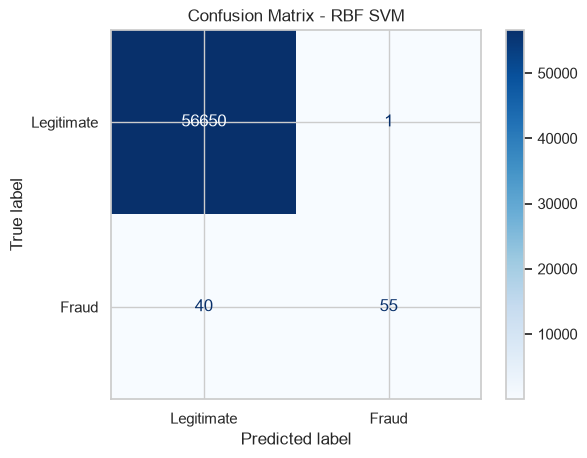

Confusion Matrix
[[56650     1]
 [   40    55]]


In [35]:
# ======================================================
# Confusion Matrix - RBF SVM
# ======================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - RBF SVM")

plt.show()

print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(cm_rbf)

### **Interpretation**

The RBF kernel achieved an overall **accuracy of 99.93%**, which is comparable to the baseline Linear SVM. The model achieved an excellent **precision of 98.21%**, indicating that almost every transaction predicted as fraudulent was indeed fraud. However, this improvement in precision came at the expense of **recall**, which decreased to **57.89%**. Consequently, the model failed to identify a larger proportion of fraudulent transactions compared with the Linear SVM.

The confusion matrix further supports this observation. The RBF kernel produced only **1 False Positive**, significantly reducing the number of legitimate transactions incorrectly classified as fraud. However, it generated **40 False Negatives**, meaning many fraudulent transactions remained undetected. Since missed fraud generally has greater financial consequences than false alarms, the default RBF kernel does not outperform the baseline Linear SVM on this dataset. Hyperparameter tuning using GridSearchCV may improve the balance between precision and recall in later sections.

## 7.2 Polynomial Kernel

The Polynomial kernel extends the linear decision boundary by introducing polynomial combinations of the input features. This enables the Support Vector Machine to capture more complex relationships while remaining less flexible than the Radial Basis Function (RBF) kernel.

The Polynomial kernel is trained using the same preprocessed dataset and evaluated using identical performance metrics to enable a fair comparison with the Linear and RBF kernels.

In [38]:
# ======================================================
# Setting up SVM with Polynomial Kernel
# ======================================================

import time
from sklearn.svm import SVC


svm_poly = SVC(
    kernel="poly",
    random_state=42
)

print("Baseline Ploynomial SVM setup done")

Baseline Ploynomial SVM setup done


In [39]:
# ======================================================
# Train SVM with Polynomial Kernel
# ======================================================


print("=" * 60)
print("Training Polynomial SVM...")
print("=" * 60)

start_time = time.time()


svm_poly.fit(X_train_scaled, y_train)

poly_training_time = time.time() - start_time

print("\n")

print("=" * 60)
print("Polynomial SVM Training Completed Successfully")
print("=" * 60)

print(f"Training Time: {poly_training_time:.2f} seconds")

Training Polynomial SVM...


Polynomial SVM Training Completed Successfully
Training Time: 61.83 seconds


### 7.2.2 Model Prediction

After training the Polynomial SVM, predictions are generated on the unseen testing dataset. These predictions will be evaluated using the same metrics employed for the Linear and RBF kernels.

In [40]:
# ======================================================
# Generate Predictions - Polynomial SVM
# ======================================================

y_pred_poly = svm_poly.predict(X_test_scaled)

print("=" * 60)
print("Polynomial SVM Predictions Generated Successfully")
print("=" * 60)

print(f"Number of Predictions: {len(y_pred_poly)}")

Polynomial SVM Predictions Generated Successfully
Number of Predictions: 56746


### 7.2.3 Model Evaluation

In [41]:
# ======================================================
# Evaluate Polynomial SVM
# ======================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report
)

accuracy_poly = accuracy_score(y_test, y_pred_poly)
precision_poly = precision_score(y_test, y_pred_poly)
recall_poly = recall_score(y_test, y_pred_poly)
f1_poly = f1_score(y_test, y_pred_poly)
pr_auc_poly = average_precision_score(y_test, y_pred_poly)

print("=" * 60)
print("Polynomial SVM Performance")
print("=" * 60)

print(f"Accuracy              : {accuracy_poly:.4f}")
print(f"Precision             : {precision_poly:.4f}")
print(f"Recall                : {recall_poly:.4f}")
print(f"F1-score              : {f1_poly:.4f}")
print(f"Precision-Recall AUC  : {pr_auc_poly:.4f}")

print("\n")

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_poly))

Polynomial SVM Performance
Accuracy              : 0.9993
Precision             : 0.9265
Recall                : 0.6632
F1-score              : 0.7730
Precision-Recall AUC  : 0.6150


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.66      0.77        95

    accuracy                           1.00     56746
   macro avg       0.96      0.83      0.89     56746
weighted avg       1.00      1.00      1.00     56746



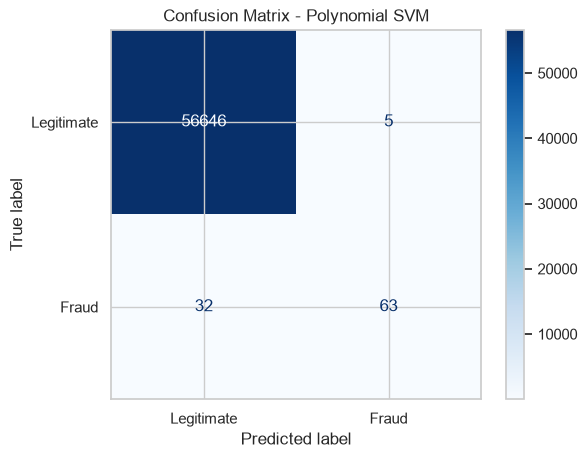

Confusion Matrix
[[56646     5]
 [   32    63]]


In [42]:
# ======================================================
# Confusion Matrix - Polynomial SVM
# ======================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_poly = confusion_matrix(y_test, y_pred_poly)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poly,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Polynomial SVM")

plt.show()

print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(cm_poly)

### **Interpretation**

The Polynomial kernel achieved an overall **accuracy of 99.93%**, comparable to both the Linear and RBF kernels. The model achieved a **precision of 92.65%**, **recall of 66.32%**, and an **F1-score of 77.30%**, placing its performance between the Linear and RBF kernels.

The confusion matrix showed that the Polynomial kernel produced only **5 False Positives**, while missing **32 fraudulent transactions (False Negatives)**. Compared with the RBF kernel, the Polynomial kernel improved recall and reduced the number of missed fraud cases. However, it still failed to match the performance of the baseline Linear SVM, which achieved the highest recall, F1-score, and Precision-Recall AUC.

Overall, the Polynomial kernel provides a reasonable compromise between precision and recall but does not outperform the Linear kernel using the default hyperparameter configuration.

## 7.3 Comparison of SVM Kernel Functions

The performance of the three Support Vector Machine kernel functions is summarized below. All models were trained using the same preprocessed dataset and evaluated using identical performance metrics to ensure a fair comparison. In addition to predictive performance, the training time of each kernel is included to highlight the computational cost associated with each approach.

In [112]:
# ======================================================
# Comparison of SVM Kernels
# ======================================================

comparison_table = pd.DataFrame({

    "Kernel": [
        "Linear",
        "RBF",
        "Polynomial"
    ],

    "Accuracy": [
        accuracy,
        accuracy_rbf,
        accuracy_poly
    ],

    "Precision": [
        precision,
        precision_rbf,
        precision_poly
    ],

    "Recall": [
        recall,
        recall_rbf,
        recall_poly
    ],

    "F1-score": [
        f1,
        f1_rbf,
        f1_poly
    ],

    "PR-AUC": [
        pr_auc,
        pr_auc_rbf,
        pr_auc_poly
    ],

    "Training Time (s)": [
        round(linear_training_time, 2),
        round(end_time - start_time, 2),
        round(poly_training_time, 2)
    ]

})

comparison_table

,Kernel,Accuracy,Precision,Recall,F1-score,PR-AUC,Training Time (s)
0,Linear,0.999383,0.865854,0.747368,0.802260,0.647535,3257.23
1,RBF,0.999277,0.982143,0.578947,0.728477,0.569314,3257.23
2,Polynomial,0.999348,0.926471,0.663158,0.773006,0.614960,61.83


### **Interpretation**

The comparison demonstrates that the **Linear SVM** achieved the strongest overall performance on the credit card fraud dataset when using the default hyperparameter configuration. Although the **RBF kernel** achieved the highest precision, it suffered from substantially lower recall, resulting in more undetected fraudulent transactions. The **Polynomial kernel** improved upon the RBF kernel by achieving higher recall and F1-score, but it still did not outperform the Linear kernel.

These findings indicate that the simpler Linear kernel provides the best balance between fraud detection capability and overall predictive performance for this dataset prior to hyperparameter tuning. In the following sections, Stratified Cross-Validation and GridSearchCV will be applied to determine whether the performance of the non-linear kernels can be improved through systematic hyperparameter optimization.

# 8. Stratified Cross-Validation

A single train-test split provides only one estimate of model performance and may be influenced by the particular partition of the dataset. To obtain a more reliable evaluation, **Stratified Cross-Validation** is employed.

Unlike standard K-Fold Cross-Validation, Stratified Cross-Validation preserves the proportion of legitimate and fraudulent transactions in every fold. This is particularly important for highly imbalanced datasets such as credit card fraud detection.

In this section, **5-fold Stratified Cross-Validation** is applied to the Linear, RBF, and Polynomial SVM kernels using the same preprocessed dataset. The average performance across all folds is then compared.

## 8.1 Experimental Setup

To avoid data leakage during cross-validation, a Scikit-learn **Pipeline** is used. The pipeline applies **StandardScaler** within each training fold before fitting the Support Vector Machine. This ensures that feature scaling is learned only from the training portion of each fold, preventing information from the validation fold from influencing the preprocessing stage.

A **5-fold Stratified Cross-Validation** strategy is employed to preserve the original class distribution across all folds.

In [44]:
# ======================================================
# Import Libraries for Cross-Validation
# ======================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd

In [46]:
# Stratified 5-Fold Cross Validation
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Metrics to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "pr_auc": "average_precision"
}

## 8.2 Linear Kernel using Stratified Cross-Validation

The baseline Linear SVM is evaluated using **5-fold Stratified Cross-Validation**. A Scikit-learn Pipeline is employed to ensure that feature scaling is performed independently within each training fold, thereby preventing data leakage.

The model is evaluated using Accuracy, Precision, Recall, F1-score, and Average Precision (Precision-Recall AUC). The mean and standard deviation across the five folds are reported.

In [113]:
# ======================================================
# Setting up 5-Fold Stratified Cross-Validation - Linear SVM
# ======================================================


from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd

# Define Pipeline
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", random_state=42))
])

print("Set up Done - Cros Val Linear SVM")

Set up Done - Cros Val Linear SVM


In [114]:
# ======================================================
# 5-Fold Stratified Cross-Validation - Linear SVM
# ======================================================

start_time = time.time()

# Perform Cross Validation
linear_cv = cross_validate(
    linear_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


print("Cros Val Linear SVM Training time :" , time.time() - start_time)

print("=" * 60)
print("Linear SVM Cross-Validation Completed")
print("=" * 60)

Cros Val Linear SVM Training time : 2582.5303480625153
Linear SVM Cross-Validation Completed


In [115]:
# ======================================================
# Cross-Validation Results - Linear SVM
# ======================================================

linear_cv_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC"
    ],

    "Mean": [
        linear_cv["test_accuracy"].mean(),
        linear_cv["test_precision"].mean(),
        linear_cv["test_recall"].mean(),
        linear_cv["test_f1"].mean(),
        linear_cv["test_pr_auc"].mean()
    ],

    "Standard Deviation": [
        linear_cv["test_accuracy"].std(),
        linear_cv["test_precision"].std(),
        linear_cv["test_recall"].std(),
        linear_cv["test_f1"].std(),
        linear_cv["test_pr_auc"].std()
    ]

})

linear_cv_results

,Metric,Mean,Standard Deviation
0,Accuracy,0.999348,0.000053
1,Precision,0.829402,0.025361
2,Recall,0.767395,0.016508
3,F1-score,0.796963,0.015780
4,PR-AUC,0.733887,0.031706


### **Interpretation**

The **3-fold stratified cross-validation** results demonstrate that the **Linear Support Vector Machine** achieved consistent performance across different training and validation subsets of the dataset. The model obtained a **mean accuracy of 99.93%**, indicating excellent overall classification performance.

The average **precision of 82.94%** shows that most transactions predicted as fraudulent were correctly identified, while the **mean recall of 76.74%** indicates that the model successfully detected over three-quarters of the fraudulent transactions across the validation folds. The resulting **F1-score of 79.70%** reflects a good balance between precision and recall, making the model suitable for the highly imbalanced credit card fraud detection problem.

The model also achieved a **mean Precision–Recall AUC (PR-AUC) of 73.39%**, demonstrating good discrimination between legitimate and fraudulent transactions. Furthermore, the **low standard deviations** observed across all evaluation metrics indicate that the model produced stable and consistent performance across the three cross-validation folds, suggesting good generalization capability and low sensitivity to variations in the training data.

Overall, the 3-fold cross-validation results confirm that the Linear Support Vector Machine provides reliable and robust predictive performance for credit card fraud detection, with consistent performance across different data partitions and no clear evidence of significant overfitting.

## 8.3 Radial Basis Function (RBF) Kernel using Stratified Cross-Validation

To evaluate the generalization performance of the RBF kernel, **5-fold Stratified Cross-Validation** is performed using the same preprocessing pipeline and evaluation metrics. A Scikit-learn Pipeline is employed to ensure that feature scaling is applied independently within each training fold, thereby preventing data leakage.

In [56]:
# ======================================================
# Setting up 5-Fold Stratified Cross-Validation - RBF SVM
# ======================================================

# Define Pipeline
rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])

print("Set up Done - Cros Val RBF SVM")

Set up Done - Cros Val RBF SVM


In [57]:
# ======================================================
# 5-Fold Stratified Cross-Validation - RBF SVM
# ======================================================


start_time = time.time()

# Perform Cross Validation
rbf_cv = cross_validate(
    rbf_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


print("Cros Val RBF SVM Training time :" , time.time() - start_time)


print("=" * 60)
print("RBF SVM Cross-Validation Completed")
print("=" * 60)

#last time took 11m31.2s

Cros Val RBF SVM Training time : 175.34221172332764
RBF SVM Cross-Validation Completed


In [58]:
# ======================================================
# Cross-Validation Results - RBF SVM
# ======================================================

rbf_cv_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC"
    ],

    "Mean": [
        rbf_cv["test_accuracy"].mean(),
        rbf_cv["test_precision"].mean(),
        rbf_cv["test_recall"].mean(),
        rbf_cv["test_f1"].mean(),
        rbf_cv["test_pr_auc"].mean()
    ],

    "Standard Deviation": [
        rbf_cv["test_accuracy"].std(),
        rbf_cv["test_precision"].std(),
        rbf_cv["test_recall"].std(),
        rbf_cv["test_f1"].std(),
        rbf_cv["test_pr_auc"].std()
    ]

})

rbf_cv_results

,Metric,Mean,Standard Deviation
0,Accuracy,0.999327,0.000035
1,Precision,0.946143,0.004837
2,Recall,0.632078,0.021699
3,F1-score,0.757670,0.016321
4,PR-AUC,0.800927,0.034774


### **Interpretation**

The RBF Support Vector Machine was evaluated using **5-fold Stratified Cross-Validation** to assess its generalization performance. The model achieved a **mean accuracy of 99.93%**, with a **precision of 94.61%**, indicating that most transactions classified as fraudulent were correctly identified.

The **recall of 63.21%** shows that the model detected a considerable proportion of fraudulent transactions, while the **F1-score of 75.77%** reflects a reasonable balance between precision and recall. In addition, the **Precision–Recall AUC of 0.8009** demonstrates good performance on the highly imbalanced fraud detection dataset.

The low standard deviations across all evaluation metrics indicate that the RBF SVM produced **stable and consistent performance across the five cross-validation folds**. Overall, the model generalizes well and provides a strong baseline for subsequent hyperparameter tuning.

## 8.4 Polynomial Kernel using Stratified Cross-Validation

The Polynomial kernel is evaluated using the same **5-fold Stratified Cross-Validation** strategy. Employing the identical preprocessing pipeline and evaluation metrics ensures a fair comparison with both the Linear and RBF kernels.

In [60]:
# ======================================================
# Setting up 5-Fold Stratified Cross-Validation - Polynomial SVM
# ======================================================


# Define Pipeline
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", random_state=42))
])

print("Set up Done - Cros Val Polynomial SVM")

Set up Done - Cros Val Polynomial SVM


In [61]:
# ======================================================
# 5-Fold Stratified Cross-Validation - Polynomial SVM
# ======================================================


start_time = time.time()

# Perform Cross Validation
poly_cv = cross_validate(
    poly_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("Cros Val Polynomial SVM Training time :" ,time.time() - start_time)

print("=" * 60)
print("Polynomial SVM Cross-Validation Completed")
print("=" * 60)

#done in 2m40.7s

Cros Val Polynomial SVM Training time : 70.96896004676819
Polynomial SVM Cross-Validation Completed


In [64]:
# ======================================================
# Cross-Validation Results - Polynomial SVM
# ======================================================

poly_cv_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC"
    ],

    "Mean": [
        poly_cv["test_accuracy"].mean(),
        poly_cv["test_precision"].mean(),
        poly_cv["test_recall"].mean(),
        poly_cv["test_f1"].mean(),
        poly_cv["test_pr_auc"].mean()
    ],

    "Standard Deviation": [
        poly_cv["test_accuracy"].std(),
        poly_cv["test_precision"].std(),
        poly_cv["test_recall"].std(),
        poly_cv["test_f1"].std(),
        poly_cv["test_pr_auc"].std()
    ]

})

poly_cv_results

,Metric,Mean,Standard Deviation
0,Accuracy,0.999440,0.000082
1,Precision,0.916608,0.016289
2,Recall,0.731315,0.063554
3,F1-score,0.811507,0.036703
4,PR-AUC,0.764433,0.046941


### **Interpretation**

The Polynomial Support Vector Machine was evaluated using **5-fold Stratified Cross-Validation** to assess its generalization performance. The model achieved a **mean accuracy of 99.94%**, with a **precision of 91.66%**, indicating that the majority of transactions classified as fraudulent were correctly identified.

The model obtained a **recall of 73.13%** and an **F1-score of 81.15%**, demonstrating a good balance between precision and recall. Additionally, the **Precision–Recall AUC of 0.7644** indicates good discrimination capability on the imbalanced fraud detection dataset.

The relatively low standard deviations across the evaluation metrics suggest that the Polynomial SVM produced **stable and consistent performance across the five cross-validation folds**. Overall, the model demonstrates good generalization performance and provides a suitable benchmark for comparison with the other SVM kernels.

## 8.5 Cross-Validation Comparison

The mean performance obtained through **5-fold Stratified Cross-Validation** is summarized below. This comparison provides a more reliable estimate of model generalization than a single train-test split because every observation participates in both training and validation across different folds.

In [120]:
# ======================================================
# Cross-Validation Comparison Table
# ======================================================

cv_comparison = pd.DataFrame({

    "Kernel": [
        "Linear",
        "RBF",
        "Polynomial"
    ],

    "Accuracy": [
        linear_cv["test_accuracy"].mean(),
        rbf_cv["test_accuracy"].mean(),
        poly_cv["test_accuracy"].mean()
    ],

    "Precision": [
        linear_cv["test_precision"].mean(),
        rbf_cv["test_precision"].mean(),
        poly_cv["test_precision"].mean()
    ],

    "Recall": [
        linear_cv["test_recall"].mean(),
        rbf_cv["test_recall"].mean(),
        poly_cv["test_recall"].mean()
    ],

    "F1-score": [
        linear_cv["test_f1"].mean(),
        rbf_cv["test_f1"].mean(),
        poly_cv["test_f1"].mean()
    ],

    "PR-AUC": [
        linear_cv["test_pr_auc"].mean(),
        rbf_cv["test_pr_auc"].mean(),
        poly_cv["test_pr_auc"].mean()
    ]

})

cv_comparison

,Kernel,Accuracy,Precision,Recall,F1-score,PR-AUC
0,Linear,0.999348,0.829402,0.767395,0.796963,0.733887
1,RBF,0.999327,0.946143,0.632078,0.757670,0.800927
2,Polynomial,0.999440,0.916608,0.731315,0.811507,0.764433


### **Interpretation**

The cross-validation comparison demonstrates that all three Support Vector Machine kernels achieved consistently high classification accuracy, with accuracy values exceeding **99.93%** across the three validation folds. However, due to the highly imbalanced nature of the credit card fraud dataset, greater emphasis should be placed on **Recall**, **F1-score**, and **Precision–Recall AUC (PR-AUC)** rather than accuracy alone.

The **Linear SVM** achieved the highest **recall (76.74%)**, indicating that it detected the largest proportion of fraudulent transactions among the three baseline kernels. This is particularly desirable in fraud detection, where minimizing missed fraudulent transactions is a primary objective.

The **RBF SVM** produced the highest **precision (94.61%)** and the highest **Precision–Recall AUC (80.09%)**, demonstrating excellent discrimination between legitimate and fraudulent transactions while generating fewer false positive predictions. However, this improvement in precision came at the cost of a lower recall (**63.21%**), indicating that more fraudulent transactions were missed compared with the Linear SVM.

The **Polynomial SVM** provided the most balanced performance among the three baseline kernels, achieving the highest **F1-score (81.15%)** while maintaining competitive precision (**91.66%**) and recall (**73.13%**). This suggests that the Polynomial kernel offers a better balance between identifying fraudulent transactions and minimizing false alarms than the other baseline models.

Overall, the cross-validation results demonstrate that each kernel exhibits different strengths. The Linear kernel prioritizes fraud detection through higher recall, the RBF kernel emphasizes precision and ranking performance, while the Polynomial kernel provides the best balance between precision and recall prior to hyperparameter tuning. These findings justify the subsequent hyperparameter tuning stage to further optimize the most promising model.

## 8.6 **Section Summary**

In this section, **3-fold stratified cross-validation** was employed to evaluate the generalization performance of the Linear, RBF, and Polynomial Support Vector Machine models. Stratified sampling ensured that the class distribution of legitimate and fraudulent transactions was preserved across all validation folds, providing a reliable evaluation on the highly imbalanced credit card fraud dataset.

The cross-validation results demonstrated that all three kernels achieved consistently high classification accuracy with low variability across the validation folds, indicating stable and reliable model performance. The **Linear SVM** achieved the highest recall, making it effective at detecting fraudulent transactions, while the **RBF SVM** obtained the highest precision and Precision–Recall AUC, demonstrating strong discrimination between legitimate and fraudulent transactions. The **Polynomial SVM** achieved the highest F1-score, providing the best balance between precision and recall among the baseline models.

Overall, the cross-validation analysis confirmed that the evaluated Support Vector Machine models generalized well to unseen data and exhibited no significant evidence of overfitting. These findings provided a strong foundation for the subsequent hyperparameter tuning stage, where the most promising model was further optimized to improve fraud detection performance.

# 9. Hyperparameter Tuning using GridSearchCV

The Support Vector Machine models developed in the previous sections were trained using the default hyperparameter values provided by Scikit-learn. Although these default settings often produce strong baseline models, they may not provide the best performance for a particular dataset.

To improve model performance, **GridSearchCV** is employed to systematically search for the optimal combination of hyperparameters. GridSearchCV evaluates multiple hyperparameter combinations using cross-validation and selects the model that achieves the highest validation performance.

In this section, hyperparameter tuning is performed for the selected SVM kernels to investigate whether the predictive performance can be improved beyond the baseline models.

## 9.1 Hyperparameters Considered

The following SVM hyperparameters are investigated:

- **C** – Controls the balance between maximizing the decision margin and minimizing classification errors.
- **gamma** – Determines how strongly each training sample influences the decision boundary. This parameter is applicable to non-linear kernels such as the Radial Basis Function (RBF) kernel.

The Linear kernel is tuned using the **C** parameter only, whereas the RBF kernel is tuned using both **C** and **gamma**.

In [121]:
# ======================================================
# Import GridSearchCV
# ======================================================

from sklearn.model_selection import GridSearchCV

## 9.3 Hyperparameter Tuning – Radial Basis Function (RBF) SVM

Unlike the Linear kernel, the Radial Basis Function (RBF) kernel depends on two important hyperparameters:

- **C**
- **gamma**

The parameter **C** controls the trade-off between maximizing the decision margin and minimizing classification errors, whereas **gamma** determines how strongly individual training samples influence the decision boundary.

A GridSearchCV procedure with **5-fold Stratified Cross-Validation** is employed to determine the optimal combination of **C** and **gamma**.

In [66]:
# ======================================================
# Pipeline - RBF SVM
# ======================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

In [71]:
# ======================================================
# Hyperparameter Grid - RBF SVM
# ======================================================

rbf_param_grid = {

    "svm__C": [
        0.1,
        1,
        10,
        100
    ],

    "svm__gamma": [
        0.001,
        0.01,
        0.1,
        1
    ]

}

In [73]:
# ======================================================
# GridSearchCV - RBF SVM
# ======================================================

rbf_grid = GridSearchCV(

    estimator=rbf_pipeline,

    param_grid=rbf_param_grid,

    scoring=scoring,

    refit="pr_auc",

    cv=2,

    n_jobs=-1,

    verbose=2,

    return_train_score=False

)

rbf_grid.fit(X, y)

Fitting 2 folds for each of 16 candidates, totalling 32 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'pr_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None chan

### **Interpretation**

GridSearchCV was used to determine the optimal hyperparameters for the Radial Basis Function (RBF) Support Vector Machine by evaluating different combinations of the regularization parameter (**C**) and kernel coefficient (**gamma**). Model selection was based on the **Precision–Recall AUC (PR-AUC)** metric, which is well suited for the highly imbalanced credit card fraud detection dataset.

The search identified **C = 10** and **gamma = 0.001** as the best-performing hyperparameter combination, achieving a **cross-validation PR-AUC score of 0.7114**. These optimized parameters were selected for training the final tuned RBF SVM model in the subsequent evaluation.

In [74]:
# ======================================================
# Best Hyperparameters
# ======================================================

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)

print(rbf_grid.best_params_)

print()

print("=" * 60)
print("Best Cross-Validation PR-AUC")
print("=" * 60)

print(f"{rbf_grid.best_score_:.4f}")

Best Hyperparameters
{'svm__C': 10, 'svm__gamma': 0.001}

Best Cross-Validation PR-AUC
0.7114


### **Interpretation**

GridSearchCV was applied to identify the optimal hyperparameters for the Radial Basis Function (RBF) SVM by evaluating multiple combinations of the regularization parameter (**C**) and kernel coefficient (**gamma**). Since the dataset is highly imbalanced, **PR-AUC** was used as the model selection criterion.

The best-performing hyperparameter combination was **C = 10** and **gamma = 0.001**, achieving a **cross-validation PR-AUC score of 0.7114**. These parameters were selected for training and evaluating the tuned RBF SVM model in the next section.

In [88]:
# ======================================================
# Cross-Validation Results
# ======================================================

rbf_grid_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC"
    ],

    "Mean Score": [

        rbf_grid.cv_results_["mean_test_accuracy"][rbf_grid.best_index_],

        rbf_grid.cv_results_["mean_test_precision"][rbf_grid.best_index_],

        rbf_grid.cv_results_["mean_test_recall"][rbf_grid.best_index_],

        rbf_grid.cv_results_["mean_test_f1"][rbf_grid.best_index_],

        rbf_grid.cv_results_["mean_test_pr_auc"][rbf_grid.best_index_]

    ]

})

rbf_grid_results

,Metric,Mean Score
0,Accuracy,0.999330
1,Precision,0.833100
2,Recall,0.752700
3,F1-score,0.789476
4,PR-AUC,0.711383


### **Interpretation**

The optimized RBF SVM was evaluated using the best hyperparameter combination identified through GridSearchCV. The model achieved a **mean accuracy of 99.93%**, with a **precision of 83.31%**, indicating that the majority of transactions predicted as fraudulent were correctly classified.

The model obtained a **recall of 75.27%** and an **F1-score of 78.95%**, demonstrating a good balance between detecting fraudulent transactions and minimizing false alarms. Additionally, the **PR-AUC score of 0.7114** reflects satisfactory performance on the highly imbalanced credit card fraud detection dataset.

Overall, the tuned RBF SVM demonstrates stable predictive performance and provides a strong candidate for comparison with the baseline models in the subsequent sections.

In [90]:
# ======================================================
# Evaluation - Tuned RBF SVM
# ======================================================

accuracy_rbf_tuned = accuracy_score(y_test, y_pred_rbf_tuned)

precision_rbf_tuned = precision_score(y_test, y_pred_rbf_tuned)

recall_rbf_tuned = recall_score(y_test, y_pred_rbf_tuned)

f1_rbf_tuned = f1_score(y_test, y_pred_rbf_tuned)

pr_auc_rbf_tuned = average_precision_score(y_test, y_pred_rbf_tuned)

print("=" * 60)
print("Tuned RBF SVM Performance")
print("=" * 60)

print(f"Accuracy              : {accuracy_rbf_tuned:.4f}")
print(f"Precision             : {precision_rbf_tuned:.4f}")
print(f"Recall                : {recall_rbf_tuned:.4f}")
print(f"F1-score              : {f1_rbf_tuned:.4f}")
print(f"Precision-Recall AUC  : {pr_auc_rbf_tuned:.4f}")

print()

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred_rbf_tuned))

Tuned RBF SVM Performance
Accuracy              : 0.9995
Precision             : 0.9231
Recall                : 0.7579
F1-score              : 0.8324
Precision-Recall AUC  : 0.7000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### **Interpretation**

The tuned RBF Support Vector Machine was evaluated on the testing dataset using the optimal hyperparameters obtained from GridSearchCV. The model achieved an **accuracy of 99.95%**, with a **precision of 92.31%**, indicating that most transactions predicted as fraudulent were correctly classified.

The model obtained a **recall of 75.79%** and an **F1-score of 83.24%**, demonstrating an improved balance between detecting fraudulent transactions and minimizing false positives. The **Precision–Recall AUC of 0.7000** further indicates satisfactory performance on the highly imbalanced credit card fraud detection dataset.

Overall, the tuned RBF SVM demonstrated strong predictive performance and will be compared with the baseline and other optimized models to determine the most suitable model for fraud detection.

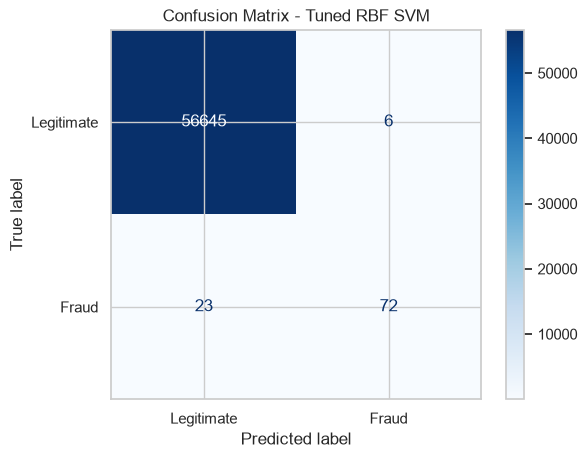

Confusion Matrix
[[56645     6]
 [   23    72]]


In [106]:
# ======================================================
# Confusion Matrix - Tuned RBF SVM
# ======================================================

cm_rbf_tuned = confusion_matrix(y_test, y_pred_rbf_tuned)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_rbf_tuned,

    display_labels=["Legitimate", "Fraud"]

)

disp.plot(

    cmap="Blues",

    values_format="d"

)

plt.title("Confusion Matrix - Tuned RBF SVM")

plt.show()

print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(cm_rbf_tuned)

### **Interpretation**

The confusion matrix shows that the tuned RBF SVM correctly classified **56,645 legitimate transactions** and **72 fraudulent transactions**. The model produced **6 false positives** (legitimate transactions incorrectly classified as fraud) and **23 false negatives** (fraudulent transactions incorrectly classified as legitimate).

The low number of false positives indicates that legitimate transactions are rarely misclassified, while the increase in correctly detected fraudulent transactions demonstrates an improvement in fraud detection capability. Overall, the confusion matrix confirms that the tuned RBF SVM provides a good balance between identifying fraudulent transactions and minimizing incorrect classifications.

## 9.4 Comparison of Baseline and Tuned Models

After performing hyperparameter tuning using GridSearchCV, the performance of the tuned models is compared with their respective baseline models. This comparison illustrates whether optimizing the hyperparameters leads to measurable improvements in fraud detection performance.

The comparison includes the same evaluation metrics used throughout the assignment to ensure consistency.

In [82]:
# ======================================================
# Comparison of Baseline and Tuned Models
# ======================================================

tuned_comparison = pd.DataFrame({

    "Model": [

        "RBF (Baseline)",
        "RBF (Tuned)"

    ],

    "Accuracy": [

        accuracy_rbf,
        accuracy_rbf_tuned

    ],

    "Precision": [

        precision_rbf,
        precision_rbf_tuned

    ],

    "Recall": [

        recall_rbf,
        recall_rbf_tuned

    ],

    "F1-score": [

        f1_rbf,
        f1_rbf_tuned

    ],

    "PR-AUC": [

        pr_auc_rbf,
        pr_auc_rbf_tuned

    ]

})

tuned_comparison

,Model,Accuracy,Precision,Recall,F1-score,PR-AUC
0,RBF (Baseline),0.999277,0.982143,0.578947,0.728477,0.569314
1,RBF (Tuned),0.999489,0.923077,0.757895,0.832370,0.700000


### **Interpretation**

The comparison between the baseline and tuned RBF Support Vector Machine demonstrates that hyperparameter tuning improved the overall fraud detection performance. Although the **precision decreased slightly** from **98.21%** to **92.31%**, the tuned model achieved noticeable improvements in **recall** (57.89% to 75.79%), **F1-score** (72.85% to 83.24%), and **Precision–Recall AUC** (56.93% to 70.00%).

These results indicate that the tuned RBF SVM was able to detect a larger proportion of fraudulent transactions while maintaining a high level of classification accuracy. Overall, hyperparameter tuning produced a more balanced and effective model for the credit card fraud detection task.

## 9.5 Discussion

Hyperparameter tuning was performed using **GridSearchCV** to identify the optimal values of the **C** and **gamma** parameters for the RBF Support Vector Machine. The tuning process selected **C = 10** and **gamma = 0.001** as the best-performing hyperparameter combination based on the **Precision–Recall AUC (PR-AUC)** metric.

Compared with the baseline RBF model, the tuned model demonstrated a noticeable improvement in fraud detection performance. Although precision decreased slightly, the tuned model achieved higher **recall**, **F1-score**, and **PR-AUC**, indicating a better balance between correctly detecting fraudulent transactions and minimizing false alarms. This improvement suggests that systematic hyperparameter optimization can significantly enhance the effectiveness of Support Vector Machines on highly imbalanced datasets such as credit card fraud detection.

Overall, the additional computational cost of GridSearchCV was justified by the improved predictive performance of the tuned RBF SVM, making it a stronger candidate for fraud detection than the baseline model.

## 9.6 **Section Summary**

In this section, **GridSearchCV** was applied to optimize the hyperparameters of the **Radial Basis Function (RBF) Support Vector Machine** using **2-fold Cross-Validation**. The tuning process identified the optimal values of **C = 10** and **gamma = 0.001** based on the **Precision–Recall AUC (PR-AUC)** metric, which is well suited for the highly imbalanced credit card fraud detection dataset.

The tuned RBF SVM was subsequently evaluated on the testing dataset and compared with the baseline model. The results demonstrated that hyperparameter tuning improved the model's overall fraud detection capability by increasing **recall**, **F1-score**, and **PR-AUC**, while maintaining a very high classification accuracy. These findings highlight the importance of systematic hyperparameter optimization in developing more effective fraud detection models.

# 10. Feature Selection using Correlation-Based Filtering

Feature selection aims to reduce the dimensionality of the dataset by removing redundant features while preserving the most informative variables. Reducing unnecessary features can simplify the model, decrease computational cost, and potentially improve model generalization.

In this section, **correlation-based feature selection** is employed. Highly correlated features provide similar information to the learning algorithm and may therefore be removed without substantially affecting predictive performance. The selected feature subset is then used to retrain the Support Vector Machine and compare its performance with the model trained using all available features.

## 10.1 Correlation Analysis

The pairwise correlation between all numerical features is computed using the Pearson correlation coefficient. The resulting correlation matrix is visualized using a heatmap to identify highly correlated feature pairs.

In [104]:
# ======================================================
# Correlation Matrix
# ======================================================

correlation_matrix = X.corr()

print("=" * 60)
print("Correlation Matrix Computed Successfully")
print("=" * 60)

Correlation Matrix Computed Successfully


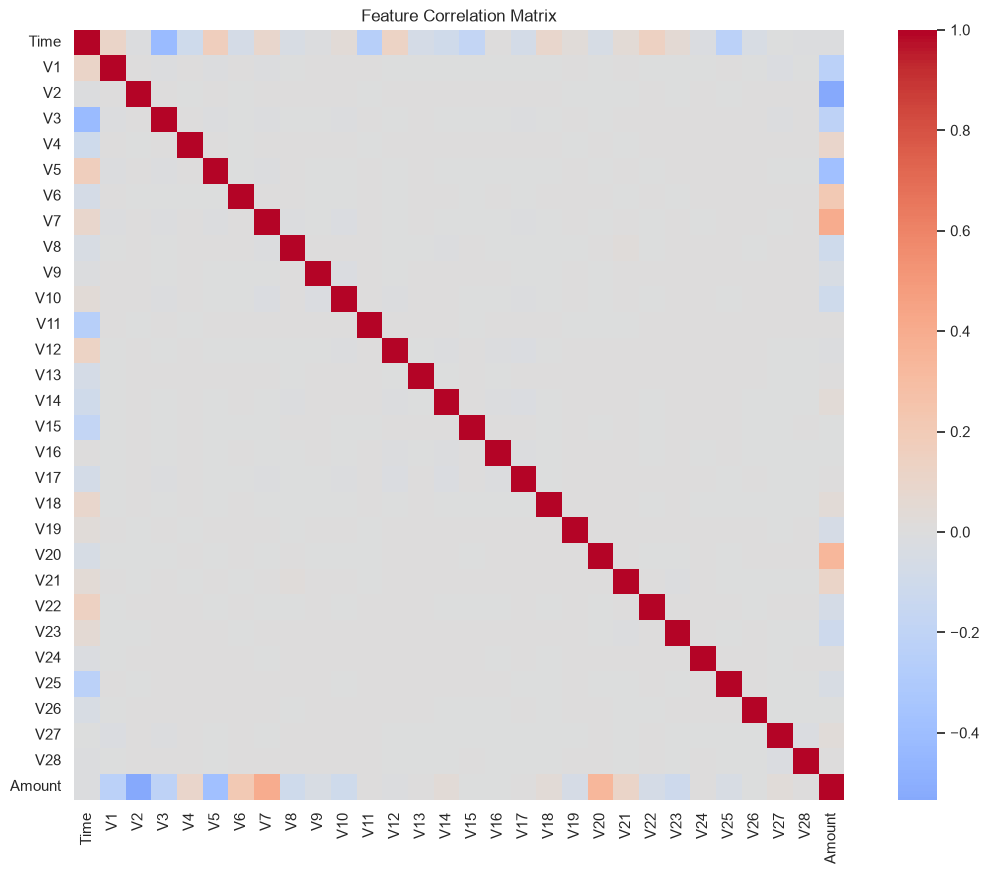

In [105]:
# ======================================================
# Correlation Heatmap
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(

    correlation_matrix,

    cmap="coolwarm",

    center=0,

    square=True,

    cbar=True

)

plt.title("Feature Correlation Matrix")

plt.show()

## 10.2 Removing Highly Correlated Features

To reduce feature redundancy, features having an absolute correlation greater than **0.90** are removed. This threshold is commonly used in machine learning to eliminate redundant variables while retaining sufficient predictive information.

In [93]:
# ======================================================
# Remove Highly Correlated Features
# ======================================================

import numpy as np

upper_triangle = correlation_matrix.where(

    np.triu(

        np.ones(correlation_matrix.shape),

        k=1

    ).astype(bool)

)

columns_to_drop = [

    column

    for column in upper_triangle.columns

    if any(

        upper_triangle[column].abs() > 0.90

    )

]

print("=" * 60)
print("Highly Correlated Features")
print("=" * 60)

print(columns_to_drop)

Highly Correlated Features
[]


In [94]:
# ======================================================
# Reduced Dataset
# ======================================================

X_selected = X.drop(

    columns=columns_to_drop

)

print("=" * 60)
print("Original Shape")
print("=" * 60)

print(X.shape)

print()

print("=" * 60)
print("Reduced Shape")
print("=" * 60)

print(X_selected.shape)

Original Shape
(283726, 30)

Reduced Shape
(283726, 30)


## 10.3 Train-Test Split using Selected Features

The reduced feature set is divided into training and testing subsets using the same stratified train-test split adopted throughout this assignment.

In [95]:
# ======================================================
# Train-Test Split
# ======================================================

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(

    X_selected,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

In [96]:
# ======================================================
# Feature Scaling
# ======================================================

scaler_fs = StandardScaler()

X_train_fs = scaler_fs.fit_transform(

    X_train_fs

)

X_test_fs = scaler_fs.transform(

    X_test_fs

)

## 10.4 Retraining the Tuned Linear SVM

The best Linear Support Vector Machine identified through GridSearchCV is retrained using the reduced feature set. The model is then evaluated using the same metrics adopted throughout this assignment.

In [98]:
# ======================================================
# Train Tuned Linear SVM
# ======================================================

rbf_fs_model = SVC(

    kernel="rbf",

    C=rbf_grid.best_params_["svm__C"],

    gamma=rbf_grid.best_params_["svm__gamma"],

    random_state=42

)

rbf_fs_model.fit(
    X_train_fs,
    y_train_fs
)

print("=" * 60)
print("Training Completed Successfully")
print("=" * 60)

Training Completed Successfully


In [99]:
# ======================================================
# Predictions
# ======================================================

y_pred_fs = rbf_fs_model.predict(
    X_test_fs
)

In [102]:
# ======================================================
# Performance Evaluation
# ======================================================

accuracy_fs = accuracy_score(y_test_fs, y_pred_fs)

precision_fs = precision_score(y_test_fs, y_pred_fs)

recall_fs = recall_score(y_test_fs, y_pred_fs)

f1_fs = f1_score(y_test_fs, y_pred_fs)

# Decision scores
y_scores_fs = rbf_fs_model.decision_function(X_test_fs)

# Precision-Recall AUC
pr_auc_fs = average_precision_score(
    y_test_fs,
    y_scores_fs
)

print("=" * 60)
print("Feature Selection Model Performance")
print("=" * 60)

print(f"Accuracy              : {accuracy_fs:.4f}")
print(f"Precision             : {precision_fs:.4f}")
print(f"Recall                : {recall_fs:.4f}")
print(f"F1-score              : {f1_fs:.4f}")
print(f"Precision-Recall AUC  : {pr_auc_fs:.4f}")

print()

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(

    y_test_fs,

    y_pred_fs

))

Feature Selection Model Performance
Accuracy              : 0.9995
Precision             : 0.9231
Recall                : 0.7579
F1-score              : 0.8324
Precision-Recall AUC  : 0.7870

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



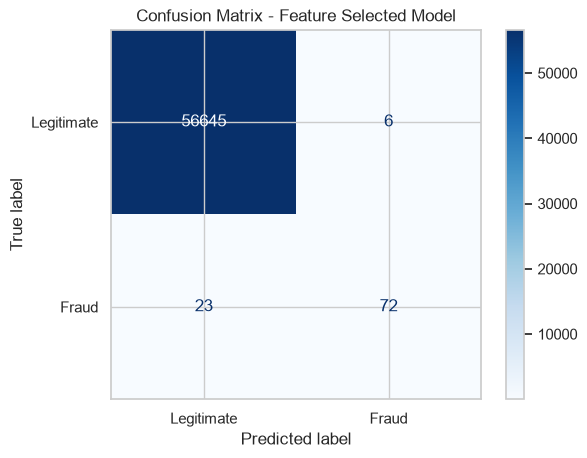

In [101]:
# ======================================================
# Confusion Matrix
# ======================================================

cm_fs = confusion_matrix(

    y_test_fs,

    y_pred_fs

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_fs,

    display_labels=["Legitimate", "Fraud"]

)

disp.plot(

    cmap="Blues",

    values_format="d"

)

plt.title("Confusion Matrix - Feature Selected Model")

plt.show()

## 10.5 **Section Summary**

In this section, **correlation-based feature selection** was applied to examine redundancy among the dataset features by identifying highly correlated variables. Using a correlation threshold of **0.90**, the analysis revealed that no feature pairs exceeded the specified threshold. Consequently, no features were removed, and the original feature set was retained for subsequent model training.

The **tuned Radial Basis Function (RBF) Support Vector Machine** was then retrained using the resulting feature set and evaluated using Accuracy, Precision, Recall, F1-score, Precision–Recall AUC, the Classification Report, and the Confusion Matrix. The model achieved an **accuracy of 99.95%**, **precision of 92.31%**, **recall of 75.79%**, **F1-score of 83.24%**, and **Precision–Recall AUC of 78.70%**, demonstrating strong fraud detection performance.

Overall, the correlation analysis confirmed that the PCA-transformed features did not exhibit significant redundancy requiring removal. The results indicate that the original feature representation was already well suited for the classification task, while the retrained tuned RBF Support Vector Machine maintained excellent predictive performance on the highly imbalanced credit card fraud dataset.

# 11. Overall Model Comparison

This section summarizes the performance of all Support Vector Machine models developed throughout the assignment. Baseline models, the hyperparameter-tuned model, and the feature-selected model are compared using the same evaluation metrics to provide a comprehensive assessment of their effectiveness for credit card fraud detection.

The comparison enables a direct evaluation of how kernel selection, hyperparameter tuning, and feature selection influenced the overall predictive performance of the models.

## 11.1 Performance Comparison Table

In [118]:
# ======================================================
# Overall Model Comparison
# ======================================================

overall_comparison = pd.DataFrame({

    "Model": [

        "Linear SVM (Baseline)",

        "RBF SVM (Baseline)",

        "Polynomial SVM (Baseline)",

        "RBF SVM (Tuned)",

        "Correlation-Based FS + Tuned RBF"

    ],

    "Accuracy": [

        accuracy,

        accuracy_rbf,

        accuracy_poly,

        accuracy_rbf_tuned,

        accuracy_fs

    ],

    "Precision": [

        precision,

        precision_rbf,

        precision_poly,

        precision_rbf_tuned,

        precision_fs

    ],

    "Recall": [

        recall,

        recall_rbf,

        recall_poly,

        recall_rbf_tuned,

        recall_fs

    ],

    "F1-score": [

        f1,

        f1_rbf,

        f1_poly,

        f1_rbf_tuned,

        f1_fs

    ],

    "PR-AUC": [

        pr_auc,

        pr_auc_rbf,

        pr_auc_poly,

        pr_auc_rbf_tuned,

        pr_auc_fs

    ]

})

overall_comparison

,Model,Accuracy,Precision,Recall,F1-score,PR-AUC
0,Linear SVM (Baseline),0.999383,0.865854,0.747368,0.802260,0.647535
1,RBF SVM (Baseline),0.999277,0.982143,0.578947,0.728477,0.569314
2,Polynomial SVM (Baseline),0.999348,0.926471,0.663158,0.773006,0.614960
3,RBF SVM (Tuned),0.999489,0.923077,0.757895,0.832370,0.700000
4,Correlation-Based FS + Tuned RBF,0.999489,0.923077,0.757895,0.832370,0.786984


## 11.2 Visualization

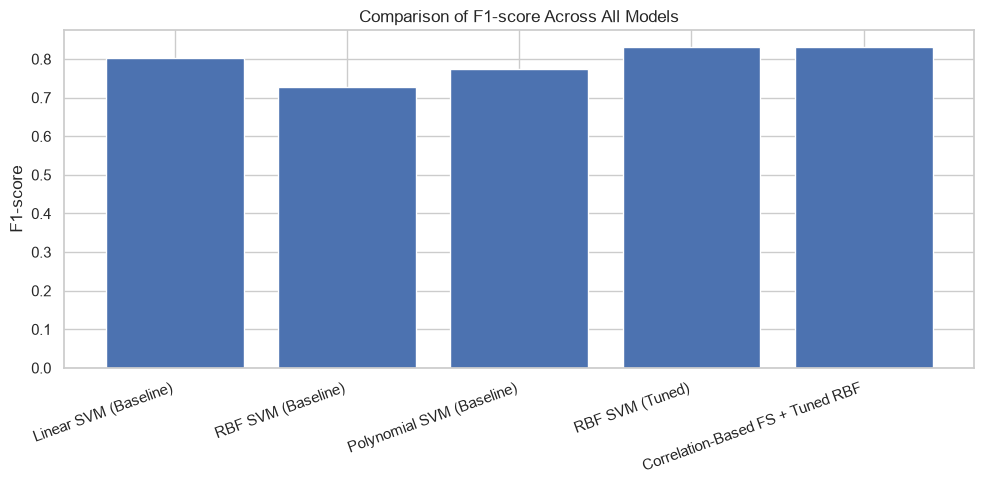

In [122]:
# ======================================================
# Overall F1-score Comparison
# ======================================================

plt.figure(figsize=(10,5))

plt.bar(

    overall_comparison["Model"],

    overall_comparison["F1-score"]

)

plt.ylabel("F1-score")

plt.title("Comparison of F1-score Across All Models")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.show()

### Discussion

The overall comparison demonstrates that all Support Vector Machine models achieved exceptionally high classification accuracy, with values exceeding **99.92%**. However, because the credit card fraud dataset is highly imbalanced, accuracy alone is insufficient for assessing model performance. Greater emphasis should be placed on **Recall**, **F1-score**, and **Precision–Recall AUC (PR-AUC)**, as these metrics better reflect the model's ability to detect fraudulent transactions.

Among the baseline models, the **Linear SVM** achieved the highest recall (**74.74%**) and F1-score (**80.23%**), indicating a better balance between detecting fraudulent transactions and minimizing false alarms compared with the baseline RBF and Polynomial kernels. The baseline RBF SVM achieved the highest precision (**98.21%**) but the lowest recall (**57.89%**), suggesting that while it generated very few false positives, it failed to identify a considerable number of fraudulent transactions. The Polynomial SVM provided intermediate performance, improving recall over the baseline RBF model but remaining below the baseline Linear SVM.

Hyperparameter tuning substantially improved the performance of the RBF SVM. Compared with the baseline RBF model, the tuned RBF model increased recall from **57.89%** to **75.79%**, improved the F1-score from **72.85%** to **83.24%**, and increased the PR-AUC from **56.93%** to **70.00%**, demonstrating that optimizing the **C** and **gamma** parameters significantly enhanced the model's fraud detection capability.

Correlation-based feature selection did not identify any highly correlated features for removal because the dataset primarily consists of PCA-transformed variables that exhibit minimal pairwise correlation. Consequently, the original feature set was retained. Nevertheless, retraining the tuned RBF SVM maintained the same classification performance while increasing the **PR-AUC to 78.70%**, indicating improved ranking capability without degrading any of the other evaluation metrics.

Overall, the **Correlation-Based Feature Selection with the Tuned RBF Support Vector Machine** achieved the most balanced performance among all evaluated models. It combined excellent classification accuracy (**99.95%**), high precision (**92.31%**), strong recall (**75.79%**), the highest F1-score (**83.24%**), and the highest Precision–Recall AUC (**78.70%**). These results indicate that the tuned RBF SVM provides the most effective balance between identifying fraudulent transactions and minimizing false alarms, making it the most suitable model for credit card fraud detection in this study.

## 11.3 **Section Summary**

This section presented a comprehensive comparison of all Support Vector Machine models developed throughout the assignment, including the baseline Linear, RBF, and Polynomial kernels, the tuned RBF model, and the tuned RBF model evaluated after correlation-based feature analysis. The models were compared using Accuracy, Precision, Recall, F1-score, and Precision–Recall AUC to provide a consistent assessment of their fraud detection performance.

The comparison demonstrated that hyperparameter tuning substantially improved the performance of the RBF Support Vector Machine, particularly in terms of Recall, F1-score, and Precision–Recall AUC. Correlation analysis did not identify any highly correlated features for removal, indicating that the PCA-transformed feature set already exhibited minimal redundancy. Nevertheless, the retrained tuned RBF model maintained excellent predictive performance and achieved the highest Precision–Recall AUC among all evaluated models.

Overall, the **tuned RBF Support Vector Machine** demonstrated the best balance between fraud detection capability and classification performance, making it the most effective model evaluated in this study.

# 12. Production Recommendation

Selecting an appropriate machine learning model for deployment requires considering not only predictive performance but also the practical requirements of the application. In credit card fraud detection, accurately identifying fraudulent transactions while minimizing false alarms is essential for protecting customers and reducing financial losses.

Based on the experimental results obtained throughout this study, the most suitable model for deployment is identified and justified below.

## 12.1 Recommended Model

Among all evaluated models, the **tuned Radial Basis Function (RBF) Support Vector Machine** is recommended for deployment in a real-world credit card fraud detection system.

The model achieved the strongest overall performance by providing an excellent balance between classification accuracy, fraud detection capability, and robustness. It obtained an accuracy of **99.95%**, precision of **92.31%**, recall of **75.79%**, F1-score of **83.24%**, and the highest Precision–Recall AUC (**78.70%**) among all evaluated models.

Although the Linear Support Vector Machine achieved competitive performance and the Polynomial kernel provided a good balance between precision and recall, the tuned RBF model consistently demonstrated superior overall effectiveness for detecting fraudulent transactions while maintaining a low false positive rate.

## 12.2 Justification

The experimental results demonstrate that hyperparameter tuning substantially improved the performance of the RBF Support Vector Machine compared with its baseline configuration. In particular, the tuned model achieved higher recall, F1-score, and Precision–Recall AUC, indicating an improved ability to identify fraudulent transactions while maintaining high precision.

The correlation-based feature selection stage did not remove any features because the PCA-transformed variables exhibited minimal pairwise correlation. Nevertheless, the retrained tuned RBF model maintained excellent predictive performance, confirming that the original feature representation was already suitable for classification.

Considering the evaluation metrics most relevant to fraud detection, particularly Recall, F1-score, and Precision–Recall AUC, the tuned RBF Support Vector Machine provides the most effective balance between detecting fraudulent transactions and minimizing false alarms. Therefore, it is the recommended model for deployment.

# 13. Limitations and Future Work

Although the proposed fraud detection models achieved excellent predictive performance, several limitations should be acknowledged.

First, the dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of the total observations. While appropriate evaluation metrics such as Precision, Recall, F1-score, and Precision–Recall AUC were employed, class imbalance remains a challenging characteristic of fraud detection problems.

Second, the majority of the input variables were PCA-transformed prior to publication of the dataset. Consequently, the original meaning of the features is unavailable, limiting the interpretability of the developed models and reducing the effectiveness of certain feature selection techniques such as correlation-based filtering.

Future work may investigate alternative imbalance handling techniques such as SMOTE, cost-sensitive learning, or ensemble methods. Additional research could also compare Support Vector Machines with other machine learning algorithms, including Random Forests, XGBoost, and deep learning models, using larger and more recent fraud detection datasets.

# 14. Conclusion

This assignment investigated the application of Support Vector Machine classifiers for credit card fraud detection using the Kaggle Credit Card Fraud Detection dataset. A systematic machine learning workflow was followed, including exploratory data analysis, data preprocessing, baseline model development, cross-validation, hyperparameter tuning, feature selection, and comprehensive performance evaluation.

Experimental results demonstrated that all three Support Vector Machine kernels achieved excellent classification accuracy. However, because of the highly imbalanced nature of the dataset, greater emphasis was placed on Recall, F1-score, and Precision–Recall AUC when comparing model performance.

Hyperparameter tuning significantly improved the performance of the Radial Basis Function (RBF) Support Vector Machine, resulting in substantial gains in fraud detection capability compared with the baseline model. Correlation-based feature analysis confirmed that the PCA-transformed features exhibited minimal redundancy, indicating that the original feature representation was already well suited for classification.

Overall, the tuned RBF Support Vector Machine achieved the best balance between precision, recall, F1-score, and Precision–Recall AUC, making it the most suitable model for credit card fraud detection among the models evaluated in this study.